# MSIN0097 Individual Coursework - Churn Prediction
Reproducible notebook scaffold aligned with the assignment brief and `src/` pipeline scripts.

## Library
All shared imports are centralized here so later cells can reuse the same dependencies without repeating imports.


In [1]:
# Library section
# All shared imports are centralized here so later cells can focus on logic rather than repeating imports.

from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix as sk_confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False

# These helper functions come from the reproducible src/ pipeline.
from src.train import train_and_select
from src.evaluate import evaluate_saved_model

# Default paths used later in modelling/evaluation sections.
DATA_PATH = Path('data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
ARTIFACT_DIR = Path('artifacts')



## 1) Obtain a dataset and frame the predictive problem
**Predictive task**: predict customer **`Churn`** (Yes/No) as a **binary classification** problem.

**Success metrics**
- Primary: **PR-AUC** (better reflects minority-class performance under class imbalance).
- Secondary: **ROC-AUC** (ranking quality across thresholds) and **F1** (precision-recall balance at an operating threshold).

**Constraints**
- Decision threshold should be **cost-sensitive** (false negatives vs false positives have different business impact).
- Balance **interpretability vs performance** when selecting the final model.

**Assumptions & limitations**
- Only use features available **at scoring time** (no future information leakage).
- Dataset is externally sourced (Kaggle: `abhinav89/telecom-customer`) and may not match every real deployment setting.
- This is predictive modelling, so we make **no causal claims**.

**Agent plan (Codex collaboration)**
- Delegate to Codex: project scaffolding, reusable pipeline code, baseline training/evaluation scripts, and test skeletons.
- Verify manually: feature validity, leakage checks, metric interpretation, threshold choices, and final modelling decisions.

In [2]:
# 1) Define a preferred dataset path and a few known alternatives.
#    This keeps notebook execution robust across different local filenames.
DATA_PATH = Path('data/telecom_customer.csv')
ALTERNATIVE_PATHS = [
    Path('data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'),
    Path('data/raw/telecom_customer.csv'),
    Path('data/raw/Telecom_customer churn.csv'),
]

# 2) Build candidate list and auto-discover CSV files inside data folders.
candidate_paths = [DATA_PATH] + ALTERNATIVE_PATHS
csv_candidates = sorted(Path('data').glob('*.csv')) + sorted(Path('data/raw').glob('*.csv'))
candidate_paths.extend(csv_candidates)

# 3) Pick the first existing CSV path.
existing = next((p for p in candidate_paths if p.exists()), None)
if existing is None:
    raise FileNotFoundError(
        'No dataset found in data/ or data/raw/. Place your CSV there or update DATA_PATH.'
    )

# 4) Load raw data unchanged for traceability.
#    All cleaning/preparation happens on derived copies in later sections.
df_raw = pd.read_csv(existing)
print(f'Loaded: {existing} | shape={df_raw.shape}')
display(df_raw.head(3))


Loaded: data/raw/Telecom_customer churn.csv | shape=(100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,0.0,N,U,Y,U,U,U,Y,1504.0,1000003


## 2) Explore the data to gain insights
Minimal, non-leaky EDA cleaning only (no imputation, no encoding, no scaling).

In [3]:
# Safety guard: if Section 1 was skipped, load raw data here so Section 2 can still run.
if 'df_raw' not in globals():
    DATA_PATH = Path('data/telecom_customer.csv')
    ALTERNATIVE_PATHS = [
        Path('data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'),
        Path('data/raw/telecom_customer.csv'),
        Path('data/raw/Telecom_customer churn.csv'),
    ]
    candidate_paths = [DATA_PATH] + ALTERNATIVE_PATHS
    candidate_paths += sorted(Path('data').glob('*.csv')) + sorted(Path('data/raw').glob('*.csv'))
    existing = next((p for p in candidate_paths if p.exists()), None)
    if existing is None:
        raise FileNotFoundError('No dataset found in data/ or data/raw/.')
    df_raw = pd.read_csv(existing)
    print(f'Auto-loaded df_raw from: {existing} | shape={df_raw.shape}')

# ------------------------------
# Section 2: Minimal EDA cleaning
# ------------------------------
# IMPORTANT: this is diagnostic cleaning only.
# We do NOT fit model preprocessing here (to avoid leakage into train/test).
df_eda = df_raw.copy()

# Standardize column names for consistent referencing in all later cells.
df_eda.columns = (
    df_eda.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^0-9a-zA-Z]+', '_', regex=True)
    .str.strip('_')
)

# Trim whitespace in string columns so categories like 'Y' and ' Y ' are unified.
obj_cols = df_eda.select_dtypes(include=['object']).columns
for c in obj_cols:
    df_eda[c] = df_eda[c].astype(str).str.strip()

# Convert common placeholder tokens into proper missing values (NaN).
missing_tokens = {'': np.nan, ' ': np.nan, 'NA': np.nan, 'N/A': np.nan, '?': np.nan}
df_eda = df_eda.replace(missing_tokens)

# Coerce numeric-like object columns into numeric dtype when appropriate.
# Rule: if at least 80% parse as numeric, treat column as numeric-like.
for c in df_eda.columns:
    if df_eda[c].dtype == 'object':
        coerced = pd.to_numeric(df_eda[c], errors='coerce')
        if coerced.notna().mean() >= 0.8:
            df_eda[c] = coerced

print('df_eda shape:', df_eda.shape)
print('dtypes (first 30):')
display(df_eda.dtypes.to_frame('dtype').head(30))

# Detect target column candidate for this churn dataset variant.
target_candidates = [c for c in ['churn', 'target', 'label', 'is_churn'] if c in df_eda.columns]
if not target_candidates:
    raise ValueError('No target-like column found. Please set target_col manually.')
target_col = target_candidates[0]
print('Using target column:', target_col)

# Create readable labels for summary tables so the diagnostics are easier to interpret.
summary_pretty_labels = {
    'numbcars': 'Known Number of Vehicles',
    'lor': 'Length of Residence',
    'income': 'Estimated Income',
    'adults': 'Number of Adults in Household',
    'avg6mou': 'Average Monthly Minutes of Use Over Previous Six Months',
    'avg6qty': 'Average Monthly Number of Calls Over Previous Six Months',
    'avg6rev': 'Average Monthly Revenue Over Previous Six Months',
    'truck': 'Truck Indicator',
    'rv': 'RV Indicator',
    'forgntvl': 'Foreign Travel Dummy Variable',
    'change_mou': 'Percentage Change in Monthly Minutes of Use vs Previous Three-Month Average',
    'change_rev': 'Percentage Change in Monthly Revenue vs Previous Three-Month Average',
}

def summary_pretty_name(col: str) -> str:
    if col in summary_pretty_labels:
        return summary_pretty_labels[col]
    if col.endswith('_mean'):
        return 'Monthly Average ' + col[:-5].replace('_', ' ').title()
    return col.replace('_', ' ').title()

# Missingness summary (count + percent), after placeholder conversion above.
missing_cnt = df_eda.isna().sum()
missing_pct = (missing_cnt / len(df_eda) * 100).round(2)
missing_summary = (
    pd.DataFrame({'missing_count': missing_cnt, 'missing_pct': missing_pct})
    .query('missing_count > 0')
    .sort_values(['missing_pct', 'missing_count'], ascending=False)
)
print('Columns with missing values:', missing_summary.shape[0])
missing_summary_display = missing_summary.head(25).copy()
missing_summary_display.index = [summary_pretty_name(c) for c in missing_summary_display.index]
display(missing_summary_display)

# Zero-value summary for numeric columns.
# In telecom usage data, zeros often represent true non-usage (informative), not missingness.
num_only = df_eda.select_dtypes(include=['number'])
zero_count = (num_only == 0).sum()
zero_pct = (zero_count / len(df_eda) * 100).round(2)
zero_summary = (
    pd.DataFrame({'zero_count': zero_count, 'zero_pct': zero_pct})
    .query('zero_count > 0')
    .sort_values(['zero_pct', 'zero_count'], ascending=False)
)
print('Numeric columns with zero values:', zero_summary.shape[0])
zero_summary_display = zero_summary.head(25).copy()
zero_summary_display.index = [summary_pretty_name(c) for c in zero_summary_display.index]
display(zero_summary_display)

# Compute churn rate with robust parsing for string/numeric target variants.
target_series = df_eda[target_col].copy()
if target_series.dtype == 'object':
    target_norm = target_series.astype(str).str.lower().str.strip()
    if set(target_norm.dropna().unique()) <= {'yes', 'no'}:
        target_bin = target_norm.map({'yes': 1, 'no': 0})
    else:
        target_bin = pd.to_numeric(target_series, errors='coerce')
else:
    target_bin = pd.to_numeric(target_series, errors='coerce')

churn_rate = target_bin.mean()
print(f'Churn rate (mean target=1): {churn_rate:.4f} ({churn_rate*100:.2f}%)')

# Simple name-based leakage scan (heuristic): flags suspicious columns for manual review.
leak_terms = ['churn', 'target', 'label', 'cancel', 'disconnect', 'termination', 'retention', 'is_churn']
leakage_cols = [c for c in df_eda.columns if any(t in c for t in leak_terms)]
print('Potential leakage/target-like columns:', leakage_cols)


df_eda shape: (100000, 100)
dtypes (first 30):


,dtype
rev_mean,float64
mou_mean,float64
totmrc_mean,float64
da_mean,float64
ovrmou_mean,float64
ovrrev_mean,float64
vceovr_mean,float64
datovr_mean,float64
roam_mean,float64
change_mou,float64


Using target column: churn
Columns with missing values: 25


,missing_count,missing_pct
Known Number of Vehicles,49366,49.37
Length of Residence,30190,30.19
Estimated Income,25436,25.44
Number of Adults in Household,23019,23.02
Average Monthly Minutes of Use Over Previous Six Months,2839,2.84
Average Monthly Number of Calls Over Previous Six Months,2839,2.84
Average Monthly Revenue Over Previous Six Months,2839,2.84
Truck Indicator,1732,1.73
RV Indicator,1732,1.73
Foreign Travel Dummy Variable,1732,1.73


Numeric columns with zero values: 65


,zero_count,zero_pct
Monthly Average Callfwdv,99567,99.57
Monthly Average Recv Sms,99128,99.13
Monthly Average Blck Dat,98772,98.77
Monthly Average Drop Dat,97400,97.40
Monthly Average Unan Dat,96880,96.88
Foreign Travel Dummy Variable,92571,92.57
Monthly Average Mou Pead,91060,91.06
Monthly Average Peak Dat,91058,91.06
Monthly Average Opk Dat,90394,90.39
Monthly Average Mou Opkd,90382,90.38


Churn rate (mean target=1): 0.4956 (49.56%)
Potential leakage/target-like columns: ['churn']


In [4]:
# ------------------------------
# Section 2A: EDA plotting setup
# ------------------------------
# This cell prepares reusable plotting objects for the later EDA cells:
# - a sampled plotting dataframe for speed
# - human-readable labels for variables and coded categories
# - selected feature lists for targeted churn relationship plots
# Run this once before the Section 2 plotting cells below.
fig_dir = Path('artifacts/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')

# Optional sampling keeps plotting responsive on a large dataset while preserving broad patterns.
plot_df = df_eda.copy()
if len(plot_df) > 20000:
    plot_df = plot_df.sample(20000, random_state=42)

# Human-readable display labels for key variables used in charts and tables.
pretty_labels = {
    'churn': 'Churn (1 = Yes, 0 = No)',
    'rev_mean': 'Mean Monthly Revenue (Charge Amount)',
    'mou_mean': 'Mean Number of Monthly Minutes of Use',
    'totmrc_mean': 'Mean Total Monthly Recurring Charge',
    'da_mean': 'Mean Number of Directory Assisted Calls',
    'ovrmou_mean': 'Mean Overage Minutes of Use',
    'ovrrev_mean': 'Mean Overage Revenue',
    'vceovr_mean': 'Mean Revenue of Voice Overage',
    'datovr_mean': 'Mean Revenue of Data Overage',
    'roam_mean': 'Mean Number of Roaming Calls',
    'months': 'Total Number of Months in Service',
    'eqpdays': 'Number of Days (Age) of Current Equipment',
    'change_mou': 'Percentage Change in Monthly Minutes of Use vs Previous Three-Month Average',
    'change_rev': 'Percentage Change in Monthly Revenue vs Previous Three-Month Average',
    'drop_vce_mean': 'Mean Number of Dropped (Failed) Voice Calls',
    'drop_dat_mean': 'Mean Number of Dropped (Failed) Data Calls',
    'drop_blk_mean': 'Mean Number of Dropped or Blocked Calls',
    'custcare_mean': 'Mean Number of Customer Care Calls',
    'totcalls': 'Total Number of Calls Over Customer Lifetime',
    'totmou': 'Total Minutes of Use Over Customer Lifetime',
    'totrev': 'Total Revenue Over Customer Lifetime',
    'adjrev': 'Billing-Adjusted Total Revenue Over Customer Lifetime',
    'adjmou': 'Billing-Adjusted Total Minutes of Use Over Customer Lifetime',
    'adjqty': 'Billing-Adjusted Total Number of Calls Over Customer Lifetime',
    'avgrev': 'Average Monthly Revenue Over Customer Lifetime',
    'avgmou': 'Average Monthly Minutes of Use Over Customer Lifetime',
    'avgqty': 'Average Monthly Number of Calls Over Customer Lifetime',
    'avg3mou': 'Average Monthly Minutes of Use Over Previous Three Months',
    'avg3qty': 'Average Monthly Number of Calls Over Previous Three Months',
    'avg3rev': 'Average Monthly Revenue Over Previous Three Months',
    'avg6mou': 'Average Monthly Minutes of Use Over Previous Six Months',
    'avg6qty': 'Average Monthly Number of Calls Over Previous Six Months',
    'avg6rev': 'Average Monthly Revenue Over Previous Six Months',
    'attempt_mean': 'Mean Number of Attempted Calls',
    'complete_mean': 'Mean Number of Completed Calls',
    'mou_cvce_mean': 'Mean Unrounded Minutes of Use of Completed Voice Calls',
    'mou_rvce_mean': 'Mean Unrounded Minutes of Use of Received Voice Calls',
    'mou_peav_mean': 'Mean Unrounded Minutes of Use of Peak Voice Calls',
    'mou_opkv_mean': 'Mean Unrounded Minutes of Use of Off-Peak Voice Calls',
    'income': 'Estimated Income',
    'adults': 'Number of Adults in Household',
    'numbcars': 'Known Number of Vehicles',
    'lor': 'Length of Residence',
    'new_cell': 'New Cell Phone User',
    'asl_flag': 'Account Spending Limit',
    'dualband': 'Dualband',
    'refurb_new': 'Handset: Refurbished or New',
    'hnd_webcap': 'Handset Web Capability',
    'truck': 'Truck Indicator',
    'rv': 'RV Indicator',
    'ownrent': 'Home Owner/Renter Status',
    'marital': 'Marital Status',
}

# Column-specific category decoding is safer than applying Y/N/U globally.
# Example: in `refurb_new`, `N` means "New" rather than "No".
category_value_maps = {
    'asl_flag': {'Y': 'Yes', 'N': 'No', 'U': 'Unknown'},
    'new_cell': {'Y': 'Yes', 'N': 'No', 'U': 'Unknown'},
    'dualband': {'Y': 'Yes', 'N': 'No', 'U': 'Unknown'},
    'truck': {'Y': 'Yes', 'N': 'No', 'U': 'Unknown'},
    'rv': {'Y': 'Yes', 'N': 'No', 'U': 'Unknown'},
    'ownrent': {'O': 'Own', 'R': 'Rent', 'U': 'Unknown'},
    'refurb_new': {'R': 'Refurbished', 'N': 'New', 'U': 'Unknown'},
    'hnd_webcap': {'UNKW': 'Unknown'},
}

def pretty_name(col: str) -> str:
    """Return a report-friendly feature label.

    This keeps figures readable for markers by replacing raw coded column names
    with business-meaning labels wherever possible.
    """
    if col in pretty_labels:
        return pretty_labels[col]
    if col.endswith('_mean'):
        base = col[:-5].replace('_', ' ').title()
        return f'Monthly Average {base}'
    return col.replace('_', ' ').title()

def format_category_value(col: str, value):
    """Convert coded category values into human-readable chart labels.

    Missing values are shown as 'Missing'. Column-specific mappings are applied
    first; otherwise the raw value is shown as text.
    """
    if pd.isna(value):
        return 'Missing'
    text = str(value).strip()
    return category_value_maps.get(col, {}).get(text, text)

def collapse_rare_categories(series: pd.Series, top_n: int = 10) -> pd.Series:
    """Keep the most frequent categories and collapse the rest into 'Other'.

    This prevents overcrowded categorical charts while preserving the main signal.
    """
    s = series.fillna('Missing').astype(str)
    keep = s.value_counts().head(top_n).index
    return s.where(s.isin(keep), 'Other')

def coerce_target_binary(series: pd.Series) -> pd.Series:
    """Convert the target to a numeric 0/1 series for EDA summaries and plots."""
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce')
    normalized = series.astype(str).str.strip().str.lower()
    mapped = normalized.map({'yes': 1, 'no': 0, 'y': 1, 'n': 0, 'true': 1, 'false': 0})
    if mapped.notna().any():
        return mapped
    return pd.to_numeric(series, errors='coerce')

# Keep a display-only copy for categorical charts.
plot_df_display = plot_df.copy()
for c in plot_df_display.select_dtypes(exclude=['number']).columns:
    plot_df_display[c] = plot_df_display[c].map(lambda v: format_category_value(c, v))

# Binary target labels make grouped charts easier to read than raw 0/1 values.
plot_target_binary = coerce_target_binary(plot_df[target_col])
plot_target_label = plot_target_binary.map({0: 'No Churn', 1: 'Churn'})

# Select a focused set of likely-important features for churn relationship analysis.
# These emphasize usage, billing, tenure, and service-friction signals.
preferred_numeric = [
    'rev_mean', 'mou_mean', 'totmrc_mean', 'months', 'eqpdays',
    'change_mou', 'change_rev', 'drop_blk_mean', 'custcare_mean',
    'ovrrev_mean', 'ovrmou_mean', 'avg3mou', 'avg6mou', 'avg3rev', 'avg6rev'
]
selected_numeric_for_churn = [c for c in preferred_numeric if c in plot_df.columns][:6]

preferred_categorical = [
    'asl_flag', 'new_cell', 'refurb_new', 'hnd_webcap',
    'dualband', 'marital', 'truck', 'rv'
]
selected_categorical_for_churn = [c for c in preferred_categorical if c in plot_df_display.columns][:4]

print('Section 2 plotting setup ready.')
print('Selected numeric features for churn analysis:', selected_numeric_for_churn)
print('Selected categorical features for churn analysis:', selected_categorical_for_churn)
print('EDA figures will be saved to:', fig_dir.resolve())



Section 2 plotting setup ready.
Selected numeric features for churn analysis: ['rev_mean', 'mou_mean', 'totmrc_mean', 'months', 'eqpdays', 'change_mou']
Selected categorical features for churn analysis: ['asl_flag', 'new_cell', 'refurb_new', 'hnd_webcap']
EDA figures will be saved to: /Users/chenliqiang/Library/CloudStorage/OneDrive-UniversityofBristol/BA/T2/Predictive/Individual/New_Predictive/artifacts/figures


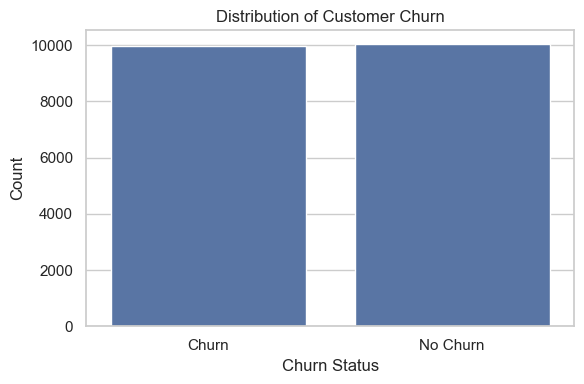

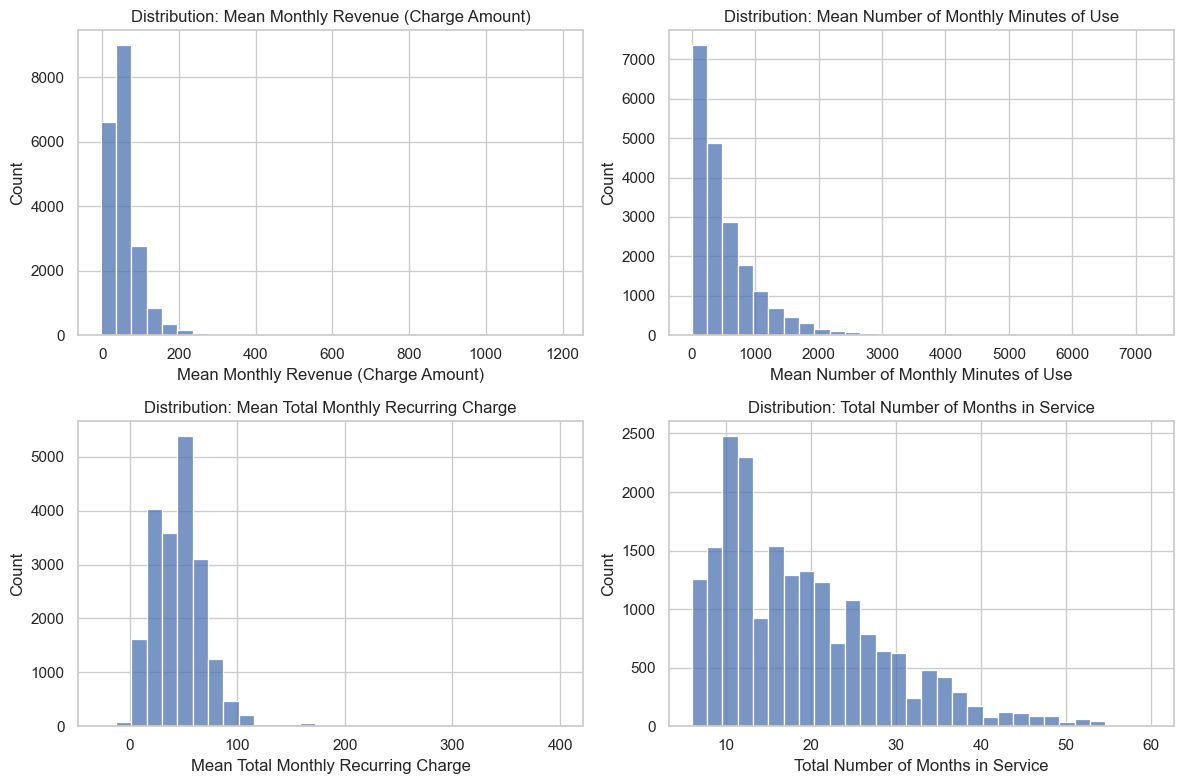

In [5]:
# ---------------------------------------------
# Section 2B: Target distribution and raw shapes
# ---------------------------------------------
# This cell gives a quick view of:
# 1) the overall churn balance
# 2) the univariate distributions of a few key numeric features before modelling
# These are descriptive plots only; no transformations are fitted here.

# Plot 1: target distribution.
plt.figure(figsize=(6, 4))
sns.countplot(x=plot_target_label.fillna('Unknown'))
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(fig_dir / 'eda_churn_distribution.png', dpi=150)
plt.show()

# Plot 2: raw numeric distributions for up to four selected numeric variables.
key_num = selected_numeric_for_churn[:4]
if key_num:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    for i, col in enumerate(key_num):
        sns.histplot(plot_df[col].dropna(), kde=False, bins=30, ax=axes[i])
        axes[i].set_title(f'Distribution: {pretty_name(col)}')
        axes[i].set_xlabel(pretty_name(col))
        axes[i].set_ylabel('Count')
    for j in range(len(key_num), 4):
        axes[j].axis('off')
    fig.tight_layout()
    fig.savefig(fig_dir / 'eda_numeric_distributions.png', dpi=150)
    plt.show()



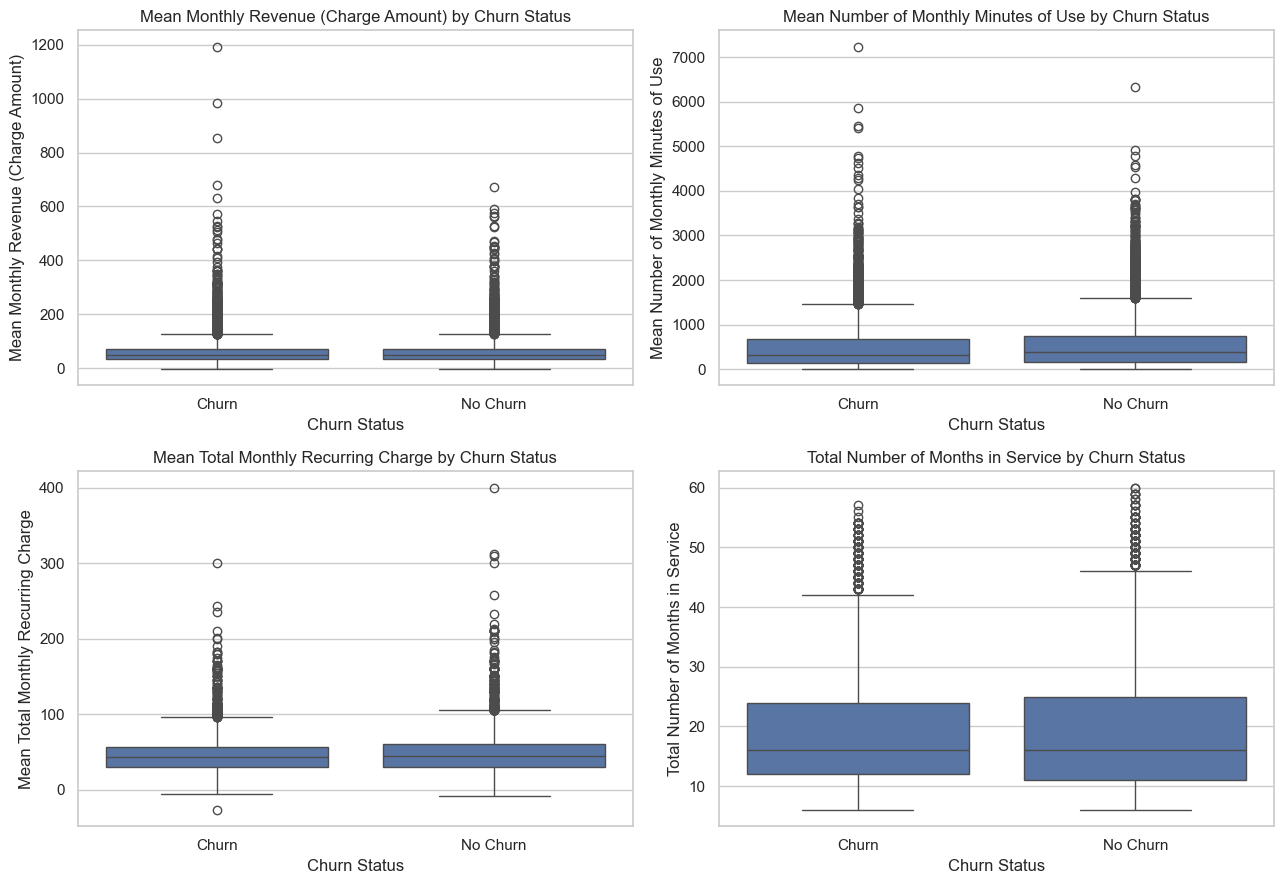

Numeric summary statistics by churn status (selected features):


,target_label,feature,mean,median,q1,q3,iqr
0,Churn,Mean Monthly Revenue (Charge Amount),58.557416,47.82625,32.78,69.903125,37.123125
1,No Churn,Mean Monthly Revenue (Charge Amount),59.298246,48.12250,33.99,71.656250,37.666250
2,Churn,Mean Number of Monthly Minutes of Use,485.610932,326.25000,134.50,666.812500,532.312500
3,No Churn,Mean Number of Monthly Minutes of Use,545.752521,380.50000,170.25,742.000000,571.750000
4,Churn,Mean Total Monthly Recurring Charge,44.475810,43.96000,29.99,56.446250,26.456250
5,No Churn,Mean Total Monthly Recurring Charge,47.875177,44.99000,30.00,59.990000,29.990000
6,Churn,Total Number of Months in Service,18.931256,16.00000,12.00,24.000000,12.000000
7,No Churn,Total Number of Months in Service,18.720986,16.00000,11.00,25.000000,14.000000
8,Churn,Number of Days (Age) of Current Equipment,418.575008,366.00000,245.00,563.000000,318.000000
9,No Churn,Number of Days (Age) of Current Equipment,364.298074,310.00000,196.00,490.000000,294.000000


In [6]:
# -------------------------------------------------------
# Section 2C: Numeric feature relationships with churn
# -------------------------------------------------------
# This cell focuses on a selective set of important numeric features.
# It shows how their distributions differ by churn status, then prints summary
# statistics by churn group (mean, median, and IQR) to support interpretation.

numeric_plot_features = selected_numeric_for_churn[:4]
if numeric_plot_features:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.flatten()
    for i, col in enumerate(numeric_plot_features):
        tmp = pd.DataFrame({
            'target_label': plot_target_label,
            col: plot_df[col],
        }).dropna()
        sns.boxplot(data=tmp, x='target_label', y=col, ax=axes[i])
        axes[i].set_title(f'{pretty_name(col)} by Churn Status')
        axes[i].set_xlabel('Churn Status')
        axes[i].set_ylabel(pretty_name(col))
    for j in range(len(numeric_plot_features), 4):
        axes[j].axis('off')
    fig.tight_layout()
    fig.savefig(fig_dir / 'eda_numeric_vs_churn_boxplots.png', dpi=150)
    plt.show()

# Summary statistics by churn group help move beyond visuals to explicit effect-size style evidence.
summary_tables = []
for col in selected_numeric_for_churn:
    tmp = pd.DataFrame({
        'target_label': plot_target_label,
        col: plot_df[col],
    }).dropna()
    if tmp.empty:
        continue
    grouped = tmp.groupby('target_label')[col]
    stats = grouped.agg(['mean', 'median'])
    q1 = grouped.quantile(0.25).rename('q1')
    q3 = grouped.quantile(0.75).rename('q3')
    stats = stats.join(q1).join(q3)
    stats['iqr'] = stats['q3'] - stats['q1']
    stats.insert(0, 'feature', pretty_name(col))
    summary_tables.append(stats.reset_index())

if summary_tables:
    numeric_churn_summary = pd.concat(summary_tables, ignore_index=True)
    print('Numeric summary statistics by churn status (selected features):')
    display(numeric_churn_summary)



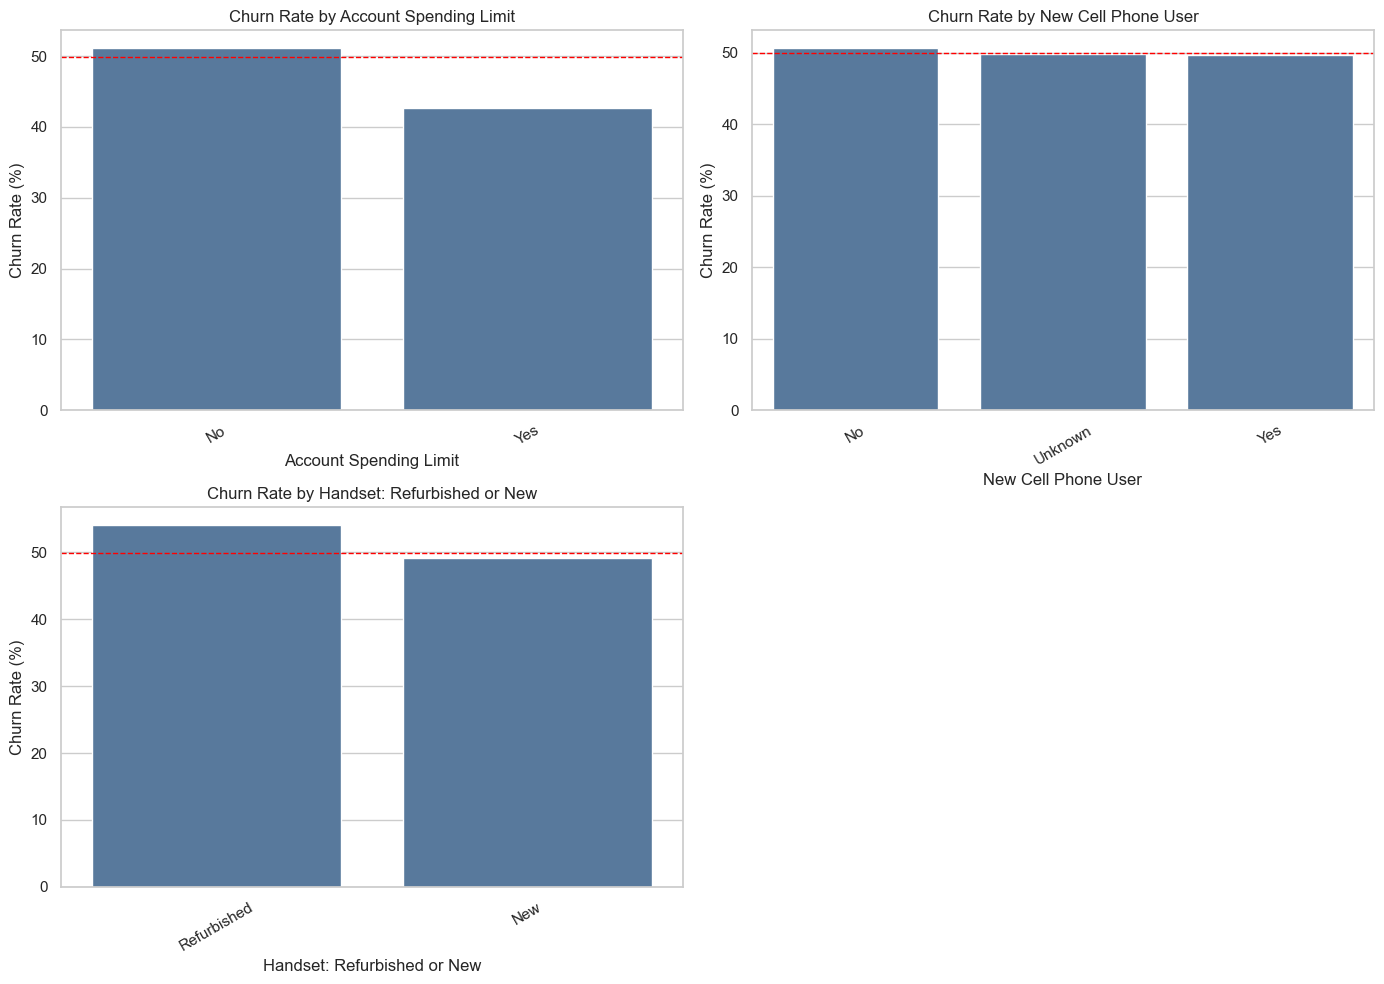

In [7]:
# -----------------------------------------------------------
# Section 2D: Categorical feature relationships with churn
# -----------------------------------------------------------
# This cell uses churn RATE by category (not raw counts only), which is more useful
# for understanding effect size. Rare categories are collapsed to 'Other' so the
# charts stay readable.

baseline_churn_rate = float(plot_target_binary.mean()) if pd.notna(plot_target_binary).any() else np.nan

# Exclude `hnd_webcap` here because its categories are currently less clean and the
# resulting chart is not especially informative for the write-up at this stage.
cat_plot_features = [c for c in selected_categorical_for_churn if c != 'hnd_webcap'][:4]

if cat_plot_features:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    for i, col in enumerate(cat_plot_features):
        tmp = pd.DataFrame({
            col: plot_df_display[col],
            'target_binary': plot_target_binary,
        }).dropna(subset=['target_binary']).copy()
        tmp[col] = collapse_rare_categories(tmp[col], top_n=10)
        rate_df = (
            tmp.groupby(col)['target_binary']
            .agg(['mean', 'size'])
            .rename(columns={'mean': 'churn_rate', 'size': 'count'})
            .reset_index()
        )
        rate_df['churn_rate_pct'] = rate_df['churn_rate'] * 100
        rate_df['churn_rate_diff_vs_overall_pct'] = (rate_df['churn_rate'] - baseline_churn_rate) * 100

        plot_rate_df = rate_df.sort_values('churn_rate_pct', ascending=False)
        sns.barplot(data=plot_rate_df, x=col, y='churn_rate_pct', ax=axes[i], color='#4C78A8')
        axes[i].axhline(baseline_churn_rate * 100, color='red', linestyle='--', linewidth=1)
        axes[i].set_title(f'Churn Rate by {pretty_name(col)}')
        axes[i].set_xlabel(pretty_name(col))
        axes[i].set_ylabel('Churn Rate (%)')
        axes[i].tick_params(axis='x', rotation=30)
    for j in range(len(cat_plot_features), 4):
        axes[j].axis('off')
    fig.tight_layout()
    fig.savefig(fig_dir / 'eda_categorical_churn_rates.png', dpi=150)
    plt.show()



Top 20 zero-inflated numeric columns:


,zero_count,zero_pct
callfwdv_mean,99567,99.57
recv_sms_mean,99128,99.13
blck_dat_mean,98772,98.77
drop_dat_mean,97400,97.40
unan_dat_mean,96880,96.88
forgntvl,92571,92.57
mou_pead_mean,91060,91.06
peak_dat_mean,91058,91.06
opk_dat_mean,90394,90.39
mou_opkd_mean,90382,90.38


Churn-rate comparison for zero vs non-zero values (top zero-inflated columns):


,feature,raw_feature_name,zero_pct,zero_churn_rate_pct,nonzero_churn_rate_pct,churn_rate_diff_nonzero_minus_zero_pct,zero_count,nonzero_count
0,Monthly Average Callfwdv,callfwdv_mean,99.57,49.584702,44.341801,-5.242900,99567,433
1,Monthly Average Recv Sms,recv_sms_mean,99.13,49.587402,46.674312,-2.913090,99128,872
2,Monthly Average Blck Dat,blck_dat_mean,98.77,49.639574,43.322476,-6.317098,98772,1228
3,Mean Number of Dropped (Failed) Data Calls,drop_dat_mean,97.40,49.634497,46.846154,-2.788343,97400,2600
4,Monthly Average Unan Dat,unan_dat_mean,96.88,49.697564,45.352564,-4.345000,96880,3120
5,Forgntvl,forgntvl,92.57,49.620903,48.586976,-1.033927,94303,5697
6,Monthly Average Mou Pead,mou_pead_mean,91.06,49.897870,46.140940,-3.756930,91060,8940
7,Monthly Average Peak Dat,peak_dat_mean,91.06,49.898965,46.130620,-3.768346,91058,8942
8,Monthly Average Opk Dat,opk_dat_mean,90.39,49.971237,45.711014,-4.260223,90394,9606
9,Monthly Average Mou Opkd,mou_opkd_mean,90.38,49.971233,45.716365,-4.254868,90382,9618


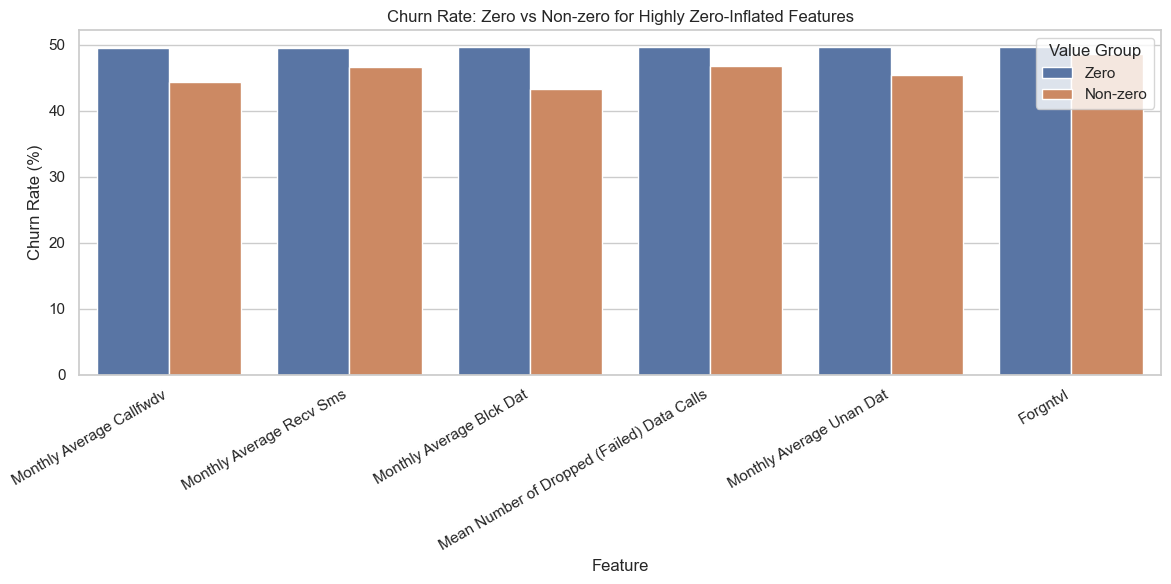

In [8]:
# ----------------------------------------
# Section 2E: Zero-inflation analysis
# ----------------------------------------
# This cell examines numeric columns with many true zero values.
# In telecom data, zero often means "no usage" rather than missingness, so this analysis
# checks whether zero vs non-zero behavior is itself predictive of churn.

# 1) Show the most zero-inflated numeric columns.
zero_top20 = zero_summary.head(20).copy()
print('Top 20 zero-inflated numeric columns:')
display(zero_top20)

# 2) For the most zero-inflated columns, compare churn rate for zero vs non-zero values.
# This is an effect-size style check: does any usage (non-zero) correspond to a different churn rate?
target_for_zero = coerce_target_binary(df_eda[target_col])
zero_inflation_rows = []

# Exclude the target itself if it appears in numeric columns.
zero_cols_for_analysis = [c for c in zero_top20.index.tolist() if c != target_col][:10]
for col in zero_cols_for_analysis:
    if col not in df_eda.columns:
        continue
    tmp = pd.DataFrame({
        col: df_eda[col],
        'target_binary': target_for_zero,
    }).dropna(subset=['target_binary']).copy()
    if tmp.empty:
        continue

    tmp['zero_group'] = np.where(tmp[col].fillna(0).eq(0), 'Zero', 'Non-zero')
    rate_df = (
        tmp.groupby('zero_group')['target_binary']
        .agg(['mean', 'size'])
        .rename(columns={'mean': 'churn_rate', 'size': 'count'})
        .reset_index()
    )

    zero_rate = rate_df.loc[rate_df['zero_group'] == 'Zero', 'churn_rate']
    nonzero_rate = rate_df.loc[rate_df['zero_group'] == 'Non-zero', 'churn_rate']
    zero_inflation_rows.append({
        'feature': pretty_name(col),
        'raw_feature_name': col,
        'zero_pct': float(zero_summary.loc[col, 'zero_pct']) if col in zero_summary.index else np.nan,
        'zero_churn_rate_pct': float(zero_rate.iloc[0] * 100) if not zero_rate.empty else np.nan,
        'nonzero_churn_rate_pct': float(nonzero_rate.iloc[0] * 100) if not nonzero_rate.empty else np.nan,
        'churn_rate_diff_nonzero_minus_zero_pct': float((nonzero_rate.iloc[0] - zero_rate.iloc[0]) * 100) if (not zero_rate.empty and not nonzero_rate.empty) else np.nan,
        'zero_count': int(rate_df.loc[rate_df['zero_group'] == 'Zero', 'count'].iloc[0]) if 'Zero' in rate_df['zero_group'].values else 0,
        'nonzero_count': int(rate_df.loc[rate_df['zero_group'] == 'Non-zero', 'count'].iloc[0]) if 'Non-zero' in rate_df['zero_group'].values else 0,
    })

zero_inflation_effects = pd.DataFrame(zero_inflation_rows)
if not zero_inflation_effects.empty:
    print('Churn-rate comparison for zero vs non-zero values (top zero-inflated columns):')
    display(zero_inflation_effects.sort_values('zero_pct', ascending=False))

    # Plot a compact comparison chart for the top 6 zero-inflated variables.
    plot_zero_effects = zero_inflation_effects.sort_values('zero_pct', ascending=False).head(6)
    plot_zero_effects = plot_zero_effects.melt(
        id_vars=['feature'],
        value_vars=['zero_churn_rate_pct', 'nonzero_churn_rate_pct'],
        var_name='group',
        value_name='churn_rate_pct',
    )
    plot_zero_effects['group'] = plot_zero_effects['group'].map({
        'zero_churn_rate_pct': 'Zero',
        'nonzero_churn_rate_pct': 'Non-zero',
    })

    plt.figure(figsize=(12, 6))
    sns.barplot(data=plot_zero_effects, x='feature', y='churn_rate_pct', hue='group')
    plt.title('Churn Rate: Zero vs Non-zero for Highly Zero-Inflated Features')
    plt.xlabel('Feature')
    plt.ylabel('Churn Rate (%)')
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Value Group')
    plt.tight_layout()
    plt.savefig(fig_dir / 'eda_zero_inflation_zero_vs_nonzero.png', dpi=150)
    plt.show()



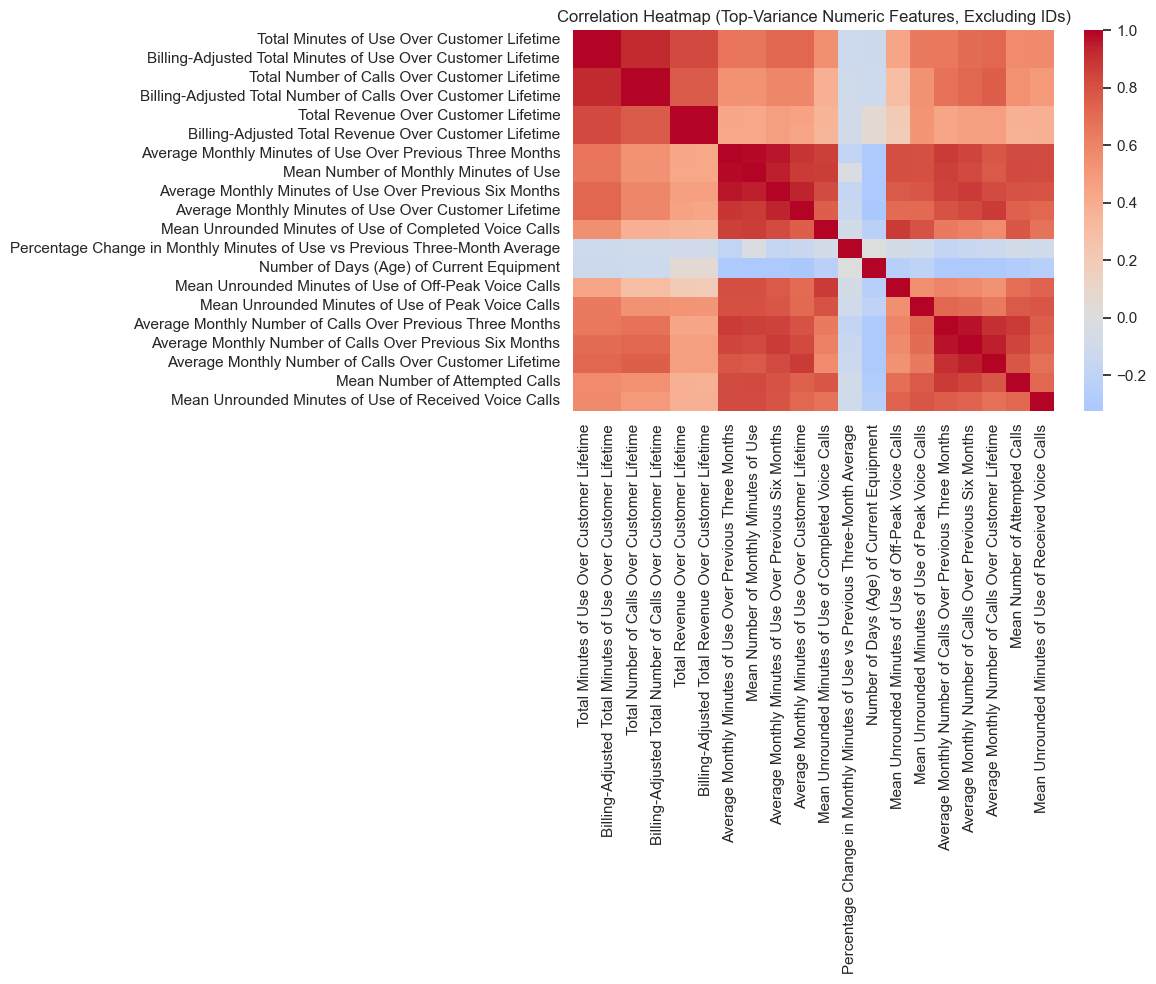

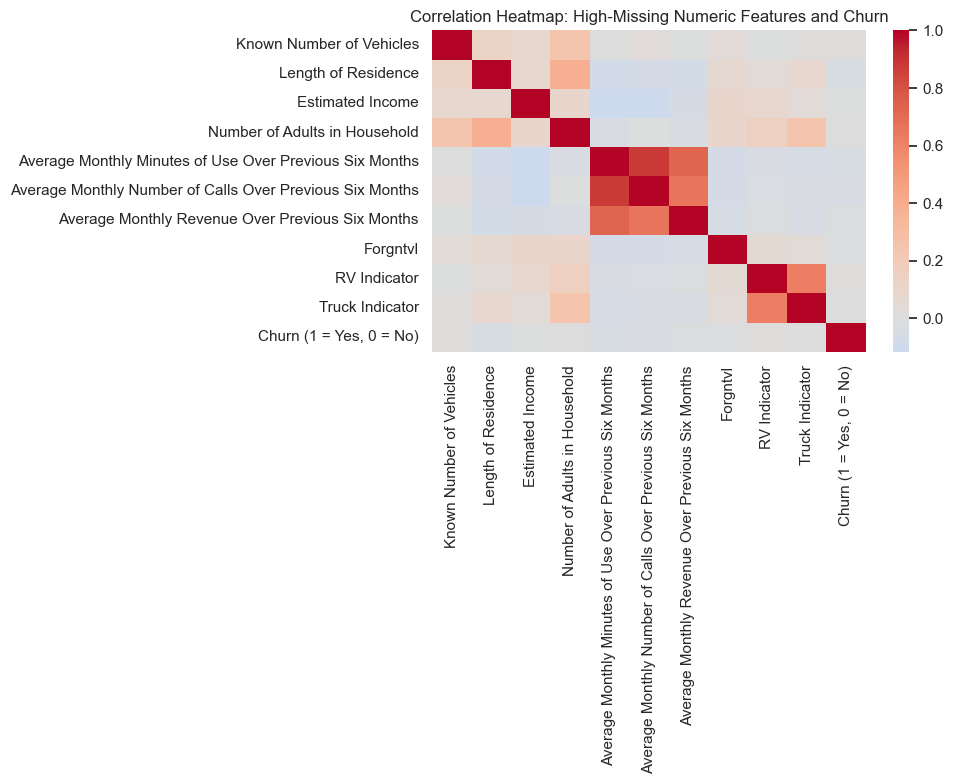

Saved EDA figures to: /Users/chenliqiang/Library/CloudStorage/OneDrive-UniversityofBristol/BA/T2/Predictive/Individual/New_Predictive/artifacts/figures


In [9]:
# ----------------------------------------
# Section 2F: Correlation heatmap diagnostics
# ----------------------------------------
# This cell provides two heatmaps:
# 1) a general top-variance numeric correlation view
# 2) a focused correlation view for the highest-missing numeric features plus churn
# These are diagnostic only and should be interpreted alongside the targeted churn plots.

# Plot 1: top-variance numeric features, excluding identifier-like numeric columns.
corr_df = plot_df.select_dtypes(include=['number']).copy()
id_like_numeric = [c for c in corr_df.columns if c in {'customer_id', 'customerid', 'id'}]
if id_like_numeric:
    corr_df = corr_df.drop(columns=id_like_numeric)
if corr_df.shape[1] > 1:
    top_var = corr_df.var(numeric_only=True).sort_values(ascending=False).head(20).index.tolist()
    corr_mat = corr_df[top_var].corr()
    pretty_corr = corr_mat.copy()
    pretty_corr.index = [pretty_name(c) for c in pretty_corr.index]
    pretty_corr.columns = [pretty_name(c) for c in pretty_corr.columns]
    plt.figure(figsize=(12, 10))
    sns.heatmap(pretty_corr, cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap (Top-Variance Numeric Features, Excluding IDs)')
    plt.tight_layout()
    plt.savefig(fig_dir / 'eda_correlation_heatmap.png', dpi=150)
    plt.show()

# Plot 2: highest-missing numeric features plus churn.
# This helps assess whether high-missing fields still show any simple linear relationship with churn.
missing_pct = df_eda.isna().mean()
high_missing_numeric = [
    c for c in missing_pct.sort_values(ascending=False).index
    if c in plot_df.select_dtypes(include=['number']).columns and c != target_col and missing_pct[c] > 0
][:10]
if high_missing_numeric:
    high_missing_corr_cols = high_missing_numeric + [target_col]
    high_missing_corr = plot_df[high_missing_corr_cols].corr()
    pretty_high_missing_corr = high_missing_corr.copy()
    pretty_high_missing_corr.index = [pretty_name(c) for c in pretty_high_missing_corr.index]
    pretty_high_missing_corr.columns = [pretty_name(c) for c in pretty_high_missing_corr.columns]
    plt.figure(figsize=(10, 8))
    sns.heatmap(pretty_high_missing_corr, cmap='coolwarm', center=0, annot=False)
    plt.title('Correlation Heatmap: High-Missing Numeric Features and Churn')
    plt.tight_layout()
    plt.savefig(fig_dir / 'eda_high_missing_correlation_heatmap.png', dpi=150)
    plt.show()

print('Saved EDA figures to:', fig_dir.resolve())



### Data Quality Issues Identified
- Missing placeholders (`''`, `' '`, `'NA'`, `'?'`) are present and standardized to `NaN` for transparent handling.
- Some object columns are numeric-like and were coerced with `errors='coerce'`, which can reveal hidden invalid tokens.
- Potential target/leakage-like fields are flagged by name for manual review before modelling.
- No imputation/encoding/scaling was applied in this EDA step to avoid premature leakage-prone transformations.

In [10]:
# Convert EDA outputs into concise narrative bullets for the report.

# Top missing columns are important for deciding Section 3 imputation strategy.
top_missing = missing_summary.head(5).copy()
print('Top missing columns:')
display(top_missing)

# Top zero-heavy columns help distinguish valid non-usage patterns from missingness.
top_zero = zero_summary.head(5).copy()
print('Top zero-heavy numeric columns:')
display(top_zero)

# Leakage flags and churn prevalence provide scope/risk context for modelling.
print('Potential leakage/target-like columns:', leakage_cols)
print(f'Observed churn rate: {churn_rate:.4f} ({churn_rate*100:.2f}%)')
print('Numeric-like object columns were coerced where >=80% parsable; review edge cases before modelling.')


Top missing columns:


,missing_count,missing_pct
numbcars,49366,49.37
lor,30190,30.19
income,25436,25.44
adults,23019,23.02
avg6mou,2839,2.84


Top zero-heavy numeric columns:


,zero_count,zero_pct
callfwdv_mean,99567,99.57
recv_sms_mean,99128,99.13
blck_dat_mean,98772,98.77
drop_dat_mean,97400,97.40
unan_dat_mean,96880,96.88


Potential leakage/target-like columns: ['churn']
Observed churn rate: 0.4956 (49.56%)
Numeric-like object columns were coerced where >=80% parsable; review edge cases before modelling.


## 3) Prepare the data
Implement leakage-safe preprocessing in the modelling pipeline (not in-place on full data).

In [11]:
# -----------------------------------------
# Section 3: Prepare data without modelling
# -----------------------------------------
# Objective:
# - define target/features
# - keep the default preparation path leakage-safe and reproducible
# - treat engineered features as a candidate extension for Section 4 ablation
# - split data with stratification
# - build leakage-safe preprocessing pipeline
# - save schema/split artifacts for reproducibility

# 1) Define target and enforce binary (0/1) values.
target_col = 'churn'
if target_col not in df_eda.columns:
    raise KeyError(f"Target column '{target_col}' not found.")

y = pd.to_numeric(df_eda[target_col], errors='coerce')
if y.isna().any():
    # Fallback mapping for string targets if needed.
    target_map = {'yes': 1, 'no': 0, 'y': 1, 'n': 0, 'true': 1, 'false': 0}
    y = df_eda[target_col].astype(str).str.strip().str.lower().map(target_map)

if y.isna().any():
    raise ValueError('Target contains unmapped values; clean/encode target first.')

y = y.astype(int)
if not set(y.unique()).issubset({0, 1}):
    raise ValueError('Target must be binary 0/1.')

# 2) Build feature matrix and drop obvious leakage/non-informational identifiers.
X = df_eda.drop(columns=[target_col]).copy()
assert target_col not in X.columns, 'Target leakage: churn found in feature matrix.'

# Customer_ID is an identifier, not a behavioral signal. Drop before training.
id_like_cols = [c for c in X.columns if c in {'customer_id', 'customerid', 'id'}]
if id_like_cols:
    X = X.drop(columns=id_like_cols)
print('Dropped ID-like columns:', id_like_cols if id_like_cols else 'None')

# Drop a small set of high-missing, lower-priority household/profile fields.
# Rationale: these columns are relatively indirect for churn, have substantial missingness,
# and are more likely to add imputation noise than robust behavioral signal in this baseline.
# The same drop list is applied before the split so train and test keep the same schema.
drop_candidates = ['numbcars', 'dwllsize', 'hhstatin', 'ownrent', 'dwlltype', 'infobase']
dropped_preparation_columns = [c for c in drop_candidates if c in X.columns]
if dropped_preparation_columns:
    X = X.drop(columns=dropped_preparation_columns)
print('Dropped high-missing preparation columns:', dropped_preparation_columns if dropped_preparation_columns else 'None')

# 3) Define a compact set of domain-driven engineered features as a candidate extension.
# These features are deterministic row-wise transforms, so creating them for ablation later
# does not leak information from the test set (no global statistics are being fit at this stage).
def add_domain_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create a small set of interpretable churn-oriented engineered features.

    Design principles:
    - use ratios and simple differences with direct business meaning
    - preserve zeros (valid non-usage) rather than converting them to missing
    - use +1 in denominators to avoid division-by-zero explosions
    - add missingness flags for high-missing demographic variables
    """
    out = df.copy()

    def has(*cols: str) -> bool:
        return all(c in out.columns for c in cols)

    def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
        """Divide safely by converting zero denominators to NaN."""
        denom = denominator.astype(float).copy()
        denom = denom.where(~np.isclose(denom, 0), np.nan)
        return numerator.astype(float) / denom

    # Usage completion / service quality features.
    if has('complete_mean', 'attempt_mean'):
        out['completion_rate'] = safe_divide(out['complete_mean'], out['attempt_mean'] + 1)
    if has('comp_vce_mean', 'plcd_vce_mean'):
        out['voice_completion_rate'] = safe_divide(out['comp_vce_mean'], out['plcd_vce_mean'] + 1)
    if has('drop_blk_mean', 'attempt_mean'):
        out['failed_call_rate'] = safe_divide(out['drop_blk_mean'], out['attempt_mean'] + 1)

    # Usage intensity / normalization by tenure.
    if has('totcalls', 'months'):
        out['calls_per_month'] = safe_divide(out['totcalls'], out['months'] + 1)
    if has('totmou', 'months'):
        out['minutes_per_month'] = safe_divide(out['totmou'], out['months'] + 1)
    if has('totrev', 'months'):
        out['revenue_per_month'] = safe_divide(out['totrev'], out['months'] + 1)

    # Billing pressure / overage burden.
    if has('ovrrev_mean', 'rev_mean'):
        out['overage_rev_share'] = safe_divide(out['ovrrev_mean'], out['rev_mean'] + 1)
    if has('ovrmou_mean', 'mou_mean'):
        out['overage_mou_share'] = safe_divide(out['ovrmou_mean'], out['mou_mean'] + 1)

    # Short-term vs medium-term trend features.
    if has('avg3mou', 'avg6mou'):
        out['mou_recent_vs_6m'] = out['avg3mou'] - out['avg6mou']
        out['mou_recent_vs_6m_pct'] = safe_divide(out['avg3mou'] - out['avg6mou'], out['avg6mou'] + 1)
    if has('avg3rev', 'avg6rev'):
        out['rev_recent_vs_6m'] = out['avg3rev'] - out['avg6rev']
        out['rev_recent_vs_6m_pct'] = safe_divide(out['avg3rev'] - out['avg6rev'], out['avg6rev'] + 1)

    # Device/account maturity.
    if has('eqpdays', 'months'):
        out['eqpdays_per_month'] = safe_divide(out['eqpdays'], out['months'] + 1)

    # Missingness indicators for high-missing demographic features.
    for col in ['income', 'numbcars', 'adults', 'lor', 'hhstatin', 'dwllsize']:
        if col in out.columns:
            out[f'{col}_missing'] = out[col].isna().astype(int)

    # Guardrail: replace any remaining non-finite numeric results (e.g. divide-by-zero) with NaN.
    numeric_cols = out.select_dtypes(include=['number']).columns
    out[numeric_cols] = out[numeric_cols].replace([np.inf, -np.inf], np.nan)

    return out

# Build the engineered-feature candidate frame for Section 4 ablation testing,
# but keep the default Section 3 training pipeline on the simpler no-engineering baseline.
raw_feature_count = X.shape[1]
X_engineered_candidate = add_domain_features(X.copy())
engineered_feature_names = [c for c in X_engineered_candidate.columns if c not in X.columns]
print(f'Raw feature count after ID/high-missing drops: {raw_feature_count}')
print(f'Candidate engineered features defined for Section 4 ablation: {len(engineered_feature_names)}')
print('Engineered feature names:', engineered_feature_names)
print('Default final Section 3 pipeline uses the no-engineering baseline unless Section 4 evidence justifies otherwise.')

# 4) Split first, preprocess later (core leakage prevention principle).
RANDOM_STATE = 42
TEST_SIZE = 0.20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Verify stratification quality by comparing class ratios across splits.
print('Train class distribution:')
display(y_train.value_counts(normalize=True).rename('proportion').to_frame())
print('Test class distribution:')
display(y_test.value_counts(normalize=True).rename('proportion').to_frame())

# 5) Programmatic feature typing.
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
object_categorical_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

# Detect binary numeric flags (0/1) and treat them as categorical features.
binary_numeric_features = []
for c in numeric_features:
    vals = set(pd.Series(X_train[c]).dropna().unique().tolist())
    if vals and vals.issubset({0, 1}):
        binary_numeric_features.append(c)

numeric_features = [c for c in numeric_features if c not in binary_numeric_features]
categorical_features = object_categorical_features + binary_numeric_features

print(f'Numeric features: {len(numeric_features)}')
print(f'Object categorical features: {len(object_categorical_features)}')
print(f'Binary numeric treated as categorical: {len(binary_numeric_features)}')
print(f'Total categorical features: {len(categorical_features)}')

# 6) Define preprocessing steps (still no model here).
# Numeric pipeline:
# - median imputation (robust to skew)
# - missingness indicators (retain missingness signal)
# - optional scaling (useful for linear models)
USE_SCALER = True
numeric_steps = [('imputer', SimpleImputer(strategy='median', add_indicator=True))]
if USE_SCALER:
    numeric_steps.append(('scaler', StandardScaler()))
numeric_transformer = Pipeline(steps=numeric_steps)

# Object categorical pipeline:
# - fill missing with 'Unknown' so absence is preserved as an explicit category
# - one-hot encode text categories
object_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

# Binary numeric categorical pipeline:
# - keep 0/1 semantics intact
# - impute missing with most frequent observed flag
# - one-hot encode so model treats flag states as categories, not continuous values
binary_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

# Combine all branches in a single leakage-safe transformer.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat_obj', object_categorical_transformer, object_categorical_features),
        ('cat_bin', binary_categorical_transformer, binary_numeric_features),
    ],
    remainder='drop',
)

# Wrap preprocessing in a pipeline so the same object can be reused later.
prep_pipeline = Pipeline(steps=[('preprocess', preprocessor)])

# 7) Validation checks before any modelling.
assert X_train.duplicated().sum() == 0, 'Duplicate rows found in X_train.'
assert not any('churn' in c.lower() for c in X_train.columns), 'Potential leakage: churn-like feature in X_train.'

# Fit preprocessing ONLY on training data.
# This prevents train-test contamination from global transform fitting.
X_train_prepared = prep_pipeline.fit_transform(X_train, y_train)
print('Transformed training feature dimension:', X_train_prepared.shape)
print(
    'Note: transformed feature count can exceed raw columns because one-hot '
    'encoding expands category levels and numeric imputation adds missing-indicator columns.'
)

# 8) Save preparation artifacts for reproducibility/auditability.
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

feature_schema = {
    'target': target_col,
    'dropped_id_columns': id_like_cols,
    'dropped_preparation_columns': dropped_preparation_columns,
    'engineered_feature_candidate_names': engineered_feature_names,
    'engineered_features_used_in_final_pipeline': False,
    'numeric_features': numeric_features,
    'object_categorical_features': object_categorical_features,
    'binary_numeric_features_as_categorical': binary_numeric_features,
    'categorical_features': categorical_features,
}
(artifacts_dir / 'feature_schema.json').write_text(
    json.dumps(feature_schema, indent=2), encoding='utf-8'
)

split_config = {
    'random_state': RANDOM_STATE,
    'test_size': TEST_SIZE,
    'n_rows_total': int(len(X)),
    'n_rows_train': int(len(X_train)),
    'n_rows_test': int(len(X_test)),
    'target_positive_rate_train': float(y_train.mean()),
    'target_positive_rate_test': float(y_test.mean()),
}
(artifacts_dir / 'split_config.json').write_text(
    json.dumps(split_config, indent=2), encoding='utf-8'
)

print('Saved:', artifacts_dir / 'feature_schema.json')
print('Saved:', artifacts_dir / 'split_config.json')


Dropped ID-like columns: ['customer_id']
Dropped high-missing preparation columns: ['numbcars', 'dwllsize', 'hhstatin', 'ownrent', 'dwlltype', 'infobase']
Raw feature count after ID/high-missing drops: 92
Candidate engineered features defined for Section 4 ablation: 16
Engineered feature names: ['completion_rate', 'voice_completion_rate', 'failed_call_rate', 'calls_per_month', 'minutes_per_month', 'revenue_per_month', 'overage_rev_share', 'overage_mou_share', 'mou_recent_vs_6m', 'mou_recent_vs_6m_pct', 'rev_recent_vs_6m', 'rev_recent_vs_6m_pct', 'eqpdays_per_month', 'income_missing', 'adults_missing', 'lor_missing']
Default final Section 3 pipeline uses the no-engineering baseline unless Section 4 evidence justifies otherwise.
Train class distribution:


,proportion
churn,
0,0.504375
1,0.495625


Test class distribution:


,proportion
churn,
0,0.5044
1,0.4956


Numeric features: 73
Object categorical features: 16
Binary numeric treated as categorical: 3
Total categorical features: 19
Transformed training feature dimension: (80000, 238)
Note: transformed feature count can exceed raw columns because one-hot encoding expands category levels and numeric imputation adds missing-indicator columns.
Saved: artifacts/feature_schema.json
Saved: artifacts/split_config.json


In [12]:
# Section 3: Engineered feature diagnostic check
# This small audit checks the candidate engineered features separately from the
# default final pipeline. The goal is to verify they are numerically well-formed
# before testing them in Section 4 ablation, not to include them by default.

engineered_feature_check = []
for col in engineered_feature_names:
    if col not in X_engineered_candidate.columns:
        continue
    s = X_engineered_candidate[col]
    engineered_feature_check.append(
        {
            'feature': col,
            'missing_pct': round(float(s.isna().mean() * 100), 2),
            'zero_pct': round(float((s.fillna(0) == 0).mean() * 100), 2) if pd.api.types.is_numeric_dtype(s) else np.nan,
            'mean': round(float(s.mean()), 4) if s.dropna().shape[0] else np.nan,
            'median': round(float(s.median()), 4) if s.dropna().shape[0] else np.nan,
            'p95': round(float(s.quantile(0.95)), 4) if s.dropna().shape[0] else np.nan,
        }
    )

engineered_feature_check_df = pd.DataFrame(engineered_feature_check)
print('Candidate engineered feature summary check:')
display(engineered_feature_check_df)
print('Interpretation: these features are defined for Section 4 testing, but they are not part of the default final Section 3 pipeline unless later evidence supports them.')


Candidate engineered feature summary check:


,feature,missing_pct,zero_pct,mean,median,p95
0,completion_rate,0.00,8.40,0.6764,0.7437,0.8787
1,voice_completion_rate,0.00,8.41,0.6758,0.7431,0.8780
2,failed_call_rate,0.00,11.87,0.0646,0.0500,0.1814
3,calls_per_month,0.00,0.02,145.9164,107.1690,406.0452
4,minutes_per_month,0.00,0.02,404.8953,302.3604,1121.7150
5,revenue_per_month,0.00,0.00,52.7173,45.7391,108.5207
6,overage_rev_share,0.36,42.91,0.1486,0.0248,0.5994
7,overage_mou_share,0.36,42.96,0.0637,0.0082,0.2866
8,mou_recent_vs_6m,2.84,4.58,6.5778,2.0000,219.0000
9,mou_recent_vs_6m_pct,2.84,4.58,-0.0026,0.0104,0.4293


Interpretation: these features are defined for Section 4 testing, but they are not part of the default final Section 3 pipeline unless later evidence supports them.


### Section 3 Rationale
- **Zero values retained**: in this telecom dataset, many zeros represent valid non-usage behavior (not missingness), so they are preserved.
- **Selective feature dropping**: a small set of high-missing, lower-priority household/profile fields (`numbcars`, `dwllsize`, `hhstatin`, `ownrent`, `dwlltype`, `infobase`) is removed to reduce imputation noise while preserving the stronger behavioral, billing, and tenure signals.
- **Candidate feature engineering**: engineered features are defined as a domain-informed extension for later ablation testing in Section 4, but they are not included in the default final Section 3 pipeline unless supported by evidence.
- **Numeric NaN strategy**: median imputation is robust to skew; `add_indicator=True` preserves missingness signal explicitly.
- **Object categorical NaN strategy**: impute to `'Unknown'` so missing category information remains visible and model-consumable.
- **Binary numeric flags as categorical**: columns limited to `{0,1}` are handled in a separate categorical branch and imputed with the most frequent observed flag, avoiding numeric-to-string type conflicts.
- **Leakage control**: preprocessing is fit **only on `X_train`** after the split, preventing test-set information from influencing training transforms.
- **Serialization safety**: the preprocessing pipeline avoids notebook-local lambda functions, so the fitted model can be saved with `joblib`.


## 4) Explore different models and shortlist the best ones
Compare candidate models and shortlist based on cross-validated evidence.

In [13]:
# Section 4: Ablation helper for feature-set tests
# This helper cell builds controlled feature-set experiments so we can test whether
# specific preparation decisions are actually helpful, rather than only assuming they are.
# Unlike the earlier single-model version, this ablation now uses the same model families
# as the main Section 4 comparison table so the feature-set conclusion is not tied to one estimator.

required_objects = ['df_eda', 'target_col', 'add_domain_features']
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(f"Run Sections 2 and 3 first. Missing objects: {missing_objects}")

SECTION3_DROP_CANDIDATES = ['numbcars', 'dwllsize', 'hhstatin', 'ownrent', 'dwlltype', 'infobase']
RANDOM_STATE = 42

# Rebuild the binary target directly from the cleaned EDA frame so each ablation uses
# the same row set and the same split rule as the main workflow.
y_ablation = pd.to_numeric(df_eda[target_col], errors='coerce')
if y_ablation.isna().any():
    target_map = {'yes': 1, 'no': 0, 'y': 1, 'n': 0, 'true': 1, 'false': 0}
    y_ablation = df_eda[target_col].astype(str).str.strip().str.lower().map(target_map)
if y_ablation.isna().any():
    raise ValueError('Target contains unmapped values; ablation target cannot be built safely.')
y_ablation = y_ablation.astype(int)

# Use the same Section 4 model families so the ablation reflects feature-set behavior
# across the benchmark models, not just one reference estimator.
def build_ablation_model_zoo() -> dict:
    model_zoo = {
        'Dummy_MostFrequent': DummyClassifier(strategy='most_frequent'),
        'LogisticRegression_balanced': LogisticRegression(
            penalty='l2',
            class_weight='balanced',
            max_iter=2000,
            random_state=RANDOM_STATE,
        ),
        'RandomForest': RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    }
    if XGBOOST_AVAILABLE:
        model_zoo['XGBoost'] = XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            eval_metric='logloss',
        )
    return model_zoo

ablation_model_zoo = build_ablation_model_zoo()

# Build a feature frame under a specific preparation design.
def build_ablation_frame(drop_selected_high_missing: bool, include_engineered_features: bool) -> pd.DataFrame:
    X = df_eda.drop(columns=[target_col]).copy()
    id_like_cols = [c for c in X.columns if c in {'customer_id', 'customerid', 'id'}]
    if id_like_cols:
        X = X.drop(columns=id_like_cols)
    if drop_selected_high_missing:
        drop_cols = [c for c in SECTION3_DROP_CANDIDATES if c in X.columns]
        if drop_cols:
            X = X.drop(columns=drop_cols)
    if include_engineered_features:
        X = add_domain_features(X)
    return X

# Build a preprocessing pipeline dynamically for an arbitrary feature frame.
# This mirrors the Section 3 rules while allowing fair comparison across feature variants.
def build_ablation_pipeline(X_train_variant: pd.DataFrame, estimator) -> Pipeline:
    numeric_features = X_train_variant.select_dtypes(include=['number']).columns.tolist()
    object_categorical_features = X_train_variant.select_dtypes(exclude=['number']).columns.tolist()

    binary_numeric_features = []
    for c in numeric_features:
        vals = set(pd.Series(X_train_variant[c]).dropna().unique().tolist())
        if vals and vals.issubset({0, 1}):
            binary_numeric_features.append(c)

    numeric_features = [c for c in numeric_features if c not in binary_numeric_features]

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('scaler', StandardScaler()),
    ])

    object_categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])

    binary_categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat_obj', object_categorical_transformer, object_categorical_features),
            ('cat_bin', binary_categorical_transformer, binary_numeric_features),
        ],
        remainder='drop',
    )

    return Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', estimator),
    ])

# Run a controlled CV comparison across named feature variants and the full Section 4 model zoo.
def run_feature_ablation(variant_frames: dict) -> pd.DataFrame:
    rows = []
    cv_ablation = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    for variant_name, X_variant in variant_frames.items():
        X_train_variant, _, y_train_variant, _ = train_test_split(
            X_variant,
            y_ablation,
            test_size=0.20,
            random_state=RANDOM_STATE,
            stratify=y_ablation,
        )

        for model_name, estimator in ablation_model_zoo.items():
            pipeline = build_ablation_pipeline(X_train_variant, estimator)

            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                cv_out = cross_validate(
                    pipeline,
                    X_train_variant,
                    y_train_variant,
                    cv=cv_ablation,
                    scoring={
                        'pr_auc': 'average_precision',
                        'roc_auc': 'roc_auc',
                        'f1': 'f1',
                    },
                    n_jobs=None,
                    return_train_score=False,
                )

            rows.append({
                'Variant': variant_name,
                'Model_Used': model_name,
                'PR-AUC_mean': float(np.mean(cv_out['test_pr_auc'])),
                'PR-AUC_std': float(np.std(cv_out['test_pr_auc'])),
                'ROC-AUC_mean': float(np.mean(cv_out['test_roc_auc'])),
                'F1_mean': float(np.mean(cv_out['test_f1'])),
            })

    return pd.DataFrame(rows).sort_values(['Model_Used', 'PR-AUC_mean'], ascending=[True, False]).reset_index(drop=True)

print(
    'Ablation helper ready. Feature-set tests will use the same model families as the main Section 4 table: '
    + ', '.join(ablation_model_zoo.keys())
)


Ablation helper ready. Feature-set tests will use the same model families as the main Section 4 table: Dummy_MostFrequent, LogisticRegression_balanced, RandomForest, HistGradientBoosting, XGBoost


In [14]:
# Section 4: Ablation Test 1 - Does dropping selected high-missing fields help?
# This test isolates the feature-dropping decision only.
# Both variants use the same CV protocol and the same Section 4 model families;
# the only difference is whether the selected high-missing household/profile fields are retained or removed.

variant_frames_drop = {
    'Keep_HighMissing_NoEngineering': build_ablation_frame(
        drop_selected_high_missing=False,
        include_engineered_features=False,
    ),
    'Drop_Selected_HighMissing_NoEngineering': build_ablation_frame(
        drop_selected_high_missing=True,
        include_engineered_features=False,
    ),
}

ablation_drop_df = run_feature_ablation(variant_frames_drop)
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)
ablation_drop_path = artifacts_dir / 'ablation_drop_test.csv'
ablation_drop_df.to_csv(ablation_drop_path, index=False)

print('Ablation Test 1: selected high-missing feature drop')
display(ablation_drop_df)
print('Interpretation: compare the two variants within each model family; if the dropped variant is equal or better on PR-AUC across the stronger models, the simplification is easier to defend.')
print('Saved:', ablation_drop_path)


Ablation Test 1: selected high-missing feature drop


,Variant,Model_Used,PR-AUC_mean,PR-AUC_std,ROC-AUC_mean,F1_mean
0,Keep_HighMissing_NoEngineering,Dummy_MostFrequent,0.495625,0.000000,0.500000,0.000000
1,Drop_Selected_HighMissing_NoEngineering,Dummy_MostFrequent,0.495625,0.000000,0.500000,0.000000
2,Drop_Selected_HighMissing_NoEngineering,HistGradientBoosting,0.676014,0.007331,0.691045,0.638337
3,Keep_HighMissing_NoEngineering,HistGradientBoosting,0.674548,0.007535,0.690724,0.638507
4,Keep_HighMissing_NoEngineering,LogisticRegression_balanced,0.608297,0.005088,0.631684,0.597989
5,Drop_Selected_HighMissing_NoEngineering,LogisticRegression_balanced,0.608184,0.004970,0.631317,0.598345
6,Drop_Selected_HighMissing_NoEngineering,RandomForest,0.653604,0.007227,0.673427,0.621175
7,Keep_HighMissing_NoEngineering,RandomForest,0.653037,0.005921,0.673718,0.620207
8,Drop_Selected_HighMissing_NoEngineering,XGBoost,0.679320,0.007777,0.693592,0.640389
9,Keep_HighMissing_NoEngineering,XGBoost,0.678496,0.007634,0.693180,0.640920


Interpretation: compare the two variants within each model family; if the dropped variant is equal or better on PR-AUC across the stronger models, the simplification is easier to defend.
Saved: artifacts/ablation_drop_test.csv


In [15]:
# Section 4: Ablation Test 2 - Do engineered features add value?
# This test isolates the feature-engineering decision.
# Both variants use the same selected high-missing drop rule and the same Section 4 model families;
# the only difference is whether the engineered features are added on top of that simplified baseline.

variant_frames_engineering = {
    'Drop_Selected_HighMissing_NoEngineering': build_ablation_frame(
        drop_selected_high_missing=True,
        include_engineered_features=False,
    ),
    'Drop_Selected_HighMissing_WithEngineering': build_ablation_frame(
        drop_selected_high_missing=True,
        include_engineered_features=True,
    ),
}

ablation_engineering_df = run_feature_ablation(variant_frames_engineering)
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)
ablation_engineering_path = artifacts_dir / 'ablation_engineering_test.csv'
ablation_engineering_df.to_csv(ablation_engineering_path, index=False)

print('Ablation Test 2: engineered feature value-add')
display(ablation_engineering_df)
print('Interpretation: compare the two variants within each model family; if the engineered-feature variant improves PR-AUC consistently, the added features are empirically justified rather than only domain-motivated.')
print('Saved:', ablation_engineering_path)


Ablation Test 2: engineered feature value-add


,Variant,Model_Used,PR-AUC_mean,PR-AUC_std,ROC-AUC_mean,F1_mean
0,Drop_Selected_HighMissing_NoEngineering,Dummy_MostFrequent,0.495625,0.000000,0.500000,0.000000
1,Drop_Selected_HighMissing_WithEngineering,Dummy_MostFrequent,0.495625,0.000000,0.500000,0.000000
2,Drop_Selected_HighMissing_NoEngineering,HistGradientBoosting,0.676014,0.007331,0.691045,0.638337
3,Drop_Selected_HighMissing_WithEngineering,HistGradientBoosting,0.674727,0.005189,0.689922,0.638125
4,Drop_Selected_HighMissing_WithEngineering,LogisticRegression_balanced,0.616291,0.003853,0.638374,0.599295
5,Drop_Selected_HighMissing_NoEngineering,LogisticRegression_balanced,0.608184,0.004970,0.631317,0.598345
6,Drop_Selected_HighMissing_NoEngineering,RandomForest,0.653604,0.007227,0.673427,0.621175
7,Drop_Selected_HighMissing_WithEngineering,RandomForest,0.652843,0.006779,0.673536,0.622183
8,Drop_Selected_HighMissing_NoEngineering,XGBoost,0.679320,0.007777,0.693592,0.640389
9,Drop_Selected_HighMissing_WithEngineering,XGBoost,0.678786,0.006068,0.693462,0.639903


Interpretation: compare the two variants within each model family; if the engineered-feature variant improves PR-AUC consistently, the added features are empirically justified rather than only domain-motivated.
Saved: artifacts/ablation_engineering_test.csv


In [16]:
# Section 4: Ablation summary and recommended feature-set choice
# This cell shows the top-performing model/variant combinations from each ablation test.
# That is more informative than averaging across model families, because it preserves
# the actual model-level ranking used to judge whether the feature change is helpful.

required_ablation_objects = ['ablation_drop_df', 'ablation_engineering_df']
missing_ablation_objects = [name for name in required_ablation_objects if name not in globals()]
if missing_ablation_objects:
    raise RuntimeError(
        'Run the Section 4 ablation helper and both ablation test cells first. Missing: '
        + ', '.join(missing_ablation_objects)
    )

# Show the strongest model/variant rows directly for each test.
top3_drop = ablation_drop_df.sort_values('PR-AUC_mean', ascending=False).head(3).reset_index(drop=True)
top3_engineering = ablation_engineering_df.sort_values('PR-AUC_mean', ascending=False).head(3).reset_index(drop=True)

best_drop_row = top3_drop.iloc[0].to_dict()
best_engineering_row = top3_engineering.iloc[0].to_dict()

print('Section 4 ablation summary: top 3 rows for Test 1 (high-missing feature drop)')
display(top3_drop)
print('Section 4 ablation summary: top 3 rows for Test 2 (engineered feature value-add)')
display(top3_engineering)

print('Recommended feature-set conclusion before the final benchmark step:')
print(
    f"- Best row in Test 1: {best_drop_row['Variant']} using {best_drop_row['Model_Used']} "
    f"(PR-AUC = {best_drop_row['PR-AUC_mean']:.6f})"
)
print(
    f"- Best row in Test 2: {best_engineering_row['Variant']} using {best_engineering_row['Model_Used']} "
    f"(PR-AUC = {best_engineering_row['PR-AUC_mean']:.6f})"
)
print('- Use these model-level ablation results as feature-set evidence, then rerun the main Section 4 comparison on the chosen final feature set.')


Section 4 ablation summary: top 3 rows for Test 1 (high-missing feature drop)


,Variant,Model_Used,PR-AUC_mean,PR-AUC_std,ROC-AUC_mean,F1_mean
0,Drop_Selected_HighMissing_NoEngineering,XGBoost,0.679320,0.007777,0.693592,0.640389
1,Keep_HighMissing_NoEngineering,XGBoost,0.678496,0.007634,0.693180,0.640920
2,Drop_Selected_HighMissing_NoEngineering,HistGradientBoosting,0.676014,0.007331,0.691045,0.638337


Section 4 ablation summary: top 3 rows for Test 2 (engineered feature value-add)


,Variant,Model_Used,PR-AUC_mean,PR-AUC_std,ROC-AUC_mean,F1_mean
0,Drop_Selected_HighMissing_NoEngineering,XGBoost,0.679320,0.007777,0.693592,0.640389
1,Drop_Selected_HighMissing_WithEngineering,XGBoost,0.678786,0.006068,0.693462,0.639903
2,Drop_Selected_HighMissing_NoEngineering,HistGradientBoosting,0.676014,0.007331,0.691045,0.638337


Recommended feature-set conclusion before the final benchmark step:
- Best row in Test 1: Drop_Selected_HighMissing_NoEngineering using XGBoost (PR-AUC = 0.679320)
- Best row in Test 2: Drop_Selected_HighMissing_NoEngineering using XGBoost (PR-AUC = 0.679320)
- Use these model-level ablation results as feature-set evidence, then rerun the main Section 4 comparison on the chosen final feature set.


In [17]:
# -----------------------------------------------
# Section 4: Explore models using cross-validation on the final dataset (missing-feature-dropped and no feature engineering)
# -----------------------------------------------
# Rule: use ONLY the training split here.
# The test set remains untouched so it stays as a clean final evaluation benchmark.
required_objects = ['prep_pipeline', 'X_train', 'y_train']
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(f"Run Section 3 first. Missing objects: {missing_objects}")

RANDOM_STATE = 42

# Cross-validation strategy used for model comparison.
# StratifiedKFold keeps the churn/non-churn ratio similar in each fold,
# so each validation fold is representative of the full training set.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 1) Define a small model zoo covering multiple families.
# This gives an evidence-based comparison across:
# - a naive baseline (DummyClassifier)
# - a linear model (Logistic Regression)
# - bagged trees (Random Forest)
# - boosted trees (HistGradientBoosting)
model_zoo = {
    'Dummy_MostFrequent': DummyClassifier(strategy='most_frequent'),
    'LogisticRegression_balanced': LogisticRegression(
        penalty='l2',
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_STATE,
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
}

# XGBoost is included as the intended boosted-tree benchmark for model comparison.
# Use the shared availability flag from the Library section so this cell does not repeat imports.
if XGBOOST_AVAILABLE:
    model_zoo['XGBoost'] = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
    )
    print('XGBoost detected and included in model zoo.')
else:
    print('XGBoost could not be imported in this environment.')

# Reuse the exact preprocessing object created in Section 3.
# This ensures model comparison is fair: each estimator gets the same cleaned inputs.
preprocess_step = prep_pipeline.named_steps['preprocess']

# 2) Evaluate each model with the same CV protocol.
# We collect mean and standard deviation across folds, plus runtime, so we can compare:
# - ranking quality (PR-AUC)
# - secondary discrimination/classification metrics (ROC-AUC, F1)
# - practical cost (fit and scoring time)
rows = []
for model_name, estimator in model_zoo.items():
    # Wrap preprocessing + estimator into a single pipeline.
    # This is critical: preprocessing must be re-fit inside each CV fold to avoid leakage.
    clf_pipeline = Pipeline(
        steps=[
            ('preprocess', clone(preprocess_step)),
            ('model', estimator),
        ]
    )

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')

        # cross_validate runs the full pipeline repeatedly across the CV folds.
        # It returns one score per fold for each metric, which we summarize below.
        cv_out = cross_validate(
            clf_pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring={
                'pr_auc': 'average_precision',
                'roc_auc': 'roc_auc',
                'f1': 'f1',
            },
            n_jobs=None,
            return_train_score=False,
        )

    # Save fold-averaged results in a report-friendly row.
    rows.append(
        {
            'Model': model_name,
            'PR-AUC_mean': float(np.mean(cv_out['test_pr_auc'])),
            'PR-AUC_std': float(np.std(cv_out['test_pr_auc'])),
            'ROC-AUC_mean': float(np.mean(cv_out['test_roc_auc'])),
            'F1_mean': float(np.mean(cv_out['test_f1'])),
            'fit_time_mean': float(np.mean(cv_out['fit_time'])),
            'score_time_mean': float(np.mean(cv_out['score_time'])),
        }
    )

# 3) Build a ranked comparison table.
# Sorting by PR-AUC keeps the shortlist aligned with the primary coursework metric.
comparison_df = pd.DataFrame(rows).sort_values('PR-AUC_mean', ascending=False).reset_index(drop=True)

# Save the comparison table so the same evidence can be reused in the report appendix.
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)
comparison_path = artifacts_dir / 'model_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)

print('Section 4 model comparison (sorted by PR-AUC):')
display(comparison_df)
print('Saved:', comparison_path)

# The top two rows become the shortlist for deeper tuning in Section 5.
# No test data is touched here.
shortlisted_models = comparison_df['Model'].head(2).tolist()
print('Top 2 shortlisted models for Section 5 tuning:', shortlisted_models)
print('Reminder: Test set has NOT been used in Section 4.')



XGBoost detected and included in model zoo.
Section 4 model comparison (sorted by PR-AUC):


,Model,PR-AUC_mean,PR-AUC_std,ROC-AUC_mean,F1_mean,fit_time_mean,score_time_mean
0,XGBoost,0.679320,0.007777,0.693592,0.640389,1.979257,0.104909
1,HistGradientBoosting,0.676014,0.007331,0.691045,0.638337,3.170051,0.240115
2,RandomForest,0.653604,0.007227,0.673427,0.621175,8.594528,0.352590
3,LogisticRegression_balanced,0.608184,0.004970,0.631317,0.598345,2.286828,0.090818
4,Dummy_MostFrequent,0.495625,0.000000,0.500000,0.000000,0.445237,0.077357


Saved: artifacts/model_comparison.csv
Top 2 shortlisted models for Section 5 tuning: ['XGBoost', 'HistGradientBoosting']
Reminder: Test set has NOT been used in Section 4.


### Section 4 Interpretation Notes
- **Feature-set selection happens first**: the ablation tests are used to refine the preparation design before the final model-family benchmark is interpreted.
- **Ablation design**: the same model families used in the main Section 4 comparison are reused in the ablation tests so the feature-set conclusion is not tied to a single estimator.
- **Ablation conclusion**: interpret the results within each model family first, then check the average PR-AUC by variant across models to decide whether the feature change is broadly helpful.
- **Primary metric is PR-AUC** because churn classification is sensitive to positive-class retrieval quality, which matters for retention targeting.
- **Secondary metrics** (ROC-AUC and F1) provide complementary checks on ranking quality and thresholded classification performance.
- **Stability across folds** is assessed using `PR-AUC_std`; lower standard deviation indicates more stable performance under resampling.
- **Shortlist for Section 5**: after fixing the feature set, use the top 2 models by PR-AUC from the main comparison table, then tune both and keep the stronger tuned result.
- **No test-set usage**: this section uses only cross-validation on `X_train`, `y_train`.


### Agent Verification Note (Section 4)
The model families in this section were informed by agent-assisted suggestions, but they were **not accepted on intuition alone**. Each candidate model was tested under the same 5-fold stratified cross-validation procedure, using **PR-AUC as the primary metric** and **ROC-AUC / F1 as secondary checks**. Models were shortlisted only if they performed better in these controlled experiments, so the decision is evidence-based rather than based on preference or “vibes”.


## 5) Fine-tune and evaluate
Tune shortlisted models and run robust error analysis on held-out data.

In [18]:
# Section 5: Lightweight tuning, threshold tuning, final evaluation
# Part 1 of 3: run focused hyperparameter searches on the top 2 models using TRAIN only.



# Confirm that the Section 3 objects already exist.
# Section 5 depends on the train/test split and preprocessing pipeline created earlier.
required_objects = ['prep_pipeline', 'X_train', 'y_train', 'X_test', 'y_test']
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(f"Run Section 3 first. Missing objects: {missing_objects}")

RANDOM_STATE = 42

# Use a lighter 3-fold CV here to keep tuning runtime manageable.
# This is a deliberate computational compromise, not a methodological change in metric choice.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Reuse the exact Section 3 preprocessing so tuning compares only model settings,
# not a changed data-cleaning pipeline.
preprocess_step = prep_pipeline.named_steps['preprocess']

# XGBoost is included as the intended boosted-tree model.
# Raise a clear error if it is unavailable, rather than failing later in the search.
if not XGBOOST_AVAILABLE:
    raise RuntimeError(
        'XGBoost could not be imported in this environment. Install/fix xgboost before running Section 5.'
    )

# Full train-only tuning pipelines: preprocessing first, then model.
# clone(preprocess_step) ensures each search gets a fresh, unfitted preprocessor.
xgb_pipeline = Pipeline(
    steps=[
        ('preprocess', clone(preprocess_step)),
        ('model', XGBClassifier(
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method='hist',
        )),
    ]
)

hgb_pipeline = Pipeline(
    steps=[
        ('preprocess', clone(preprocess_step)),
        ('model', HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]
)

# Candidate hyperparameter spaces.
# RandomizedSearchCV will sample random combinations from these lists,
# rather than evaluating every possible Cartesian-product combination.
xgb_param_dist = {
    'model__n_estimators': [200, 400, 600, 800],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'model__max_depth': [2, 3, 4, 5],
    'model__min_child_weight': [1, 3, 5, 8],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__gamma': [0, 0.1, 0.3, 0.5],
    'model__reg_alpha': [0, 0.1, 0.5, 1.0],
    'model__reg_lambda': [1.0, 3.0, 10.0],
}

hgb_param_dist = {
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__max_depth': [2, 3, 4, None],
    'model__max_leaf_nodes': [15, 31, 63, 127],
    'model__min_samples_leaf': [10, 20, 50, 100],
    'model__l2_regularization': [0.0, 0.1, 1.0, 10.0],
    'model__max_iter': [200, 400, 800],
}

# Randomized search settings.
# - scoring='average_precision' keeps PR-AUC as the primary tuning criterion.
# - refit=True means the best parameter setting is re-fit on all of X_train at the end.
# - return_train_score=True lets us inspect overfitting risk in the saved results.
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=15,
    scoring='average_precision',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=None,
    refit=True,
    return_train_score=True,
)

hgb_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=hgb_param_dist,
    n_iter=15,
    scoring='average_precision',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=None,
    refit=True,
    return_train_score=True,
)

# Execute both searches on TRAIN only.
# The test set is still untouched at this point.
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    print('Running RandomizedSearchCV for XGBoost...')
    xgb_search.fit(X_train, y_train)
    print('Running RandomizedSearchCV for HistGradientBoosting...')
    hgb_search.fit(X_train, y_train)

# Helper function: extract the best-performing parameter rows into a tidy table.
# This makes the tuning output easier to review and cite in the report.
def top_results_table(search, model_name: str) -> pd.DataFrame:
    """Return the top 10 parameter settings from a fitted RandomizedSearchCV object."""
    cols = ['mean_test_score', 'std_test_score', 'mean_train_score', 'rank_test_score', 'params']
    out = pd.DataFrame(search.cv_results_)[cols].sort_values('rank_test_score').head(10).copy()
    out.insert(0, 'Model', model_name)
    return out

xgb_top = top_results_table(xgb_search, 'XGBoost')
hgb_top = top_results_table(hgb_search, 'HistGradientBoosting')
combined_top = pd.concat([xgb_top, hgb_top], ignore_index=True)

# Prepare output locations.
# These artifacts provide a persistent audit trail of the tuning decision.
artifacts_dir = Path('artifacts')
fig_dir = artifacts_dir / 'figures'
artifacts_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

# Save the top tuning rows for both tuned candidates.
tuning_results_path = artifacts_dir / 'tuning_results.csv'
combined_top.to_csv(tuning_results_path, index=False)

# Save a compact JSON summary for quick reference.
tuning_summary = {
    'XGBoost': {
        'best_score_cv_average_precision': float(xgb_search.best_score_),
        'best_params': xgb_search.best_params_,
        'cv_folds': 3,
        'n_iter': 15,
    },
    'HistGradientBoosting': {
        'best_score_cv_average_precision': float(hgb_search.best_score_),
        'best_params': hgb_search.best_params_,
        'cv_folds': 3,
        'n_iter': 15,
    },
}

summary_path = artifacts_dir / 'tuning_summary.json'
summary_path.write_text(json.dumps(tuning_summary, indent=2), encoding='utf-8')

# Compare tuned candidates on their best CV PR-AUC and carry the stronger one forward.
# This keeps model selection train-only and avoids using the test set to choose the winner.
if xgb_search.best_score_ >= hgb_search.best_score_:
    final_model_name = 'XGBoost'
    final_pipeline = xgb_search.best_estimator_
else:
    final_model_name = 'HistGradientBoosting'
    final_pipeline = hgb_search.best_estimator_

best_model_path = artifacts_dir / 'best_model.joblib'
joblib.dump(final_pipeline, best_model_path)

print('Tuning summary (training CV only):')
print(json.dumps(tuning_summary, indent=2))
print('Saved:', tuning_results_path)
print('Saved:', summary_path)
print('Selected final model:', final_model_name)
print('Saved:', best_model_path)



Running RandomizedSearchCV for XGBoost...
Running RandomizedSearchCV for HistGradientBoosting...
Tuning summary (training CV only):
{
  "XGBoost": {
    "best_score_cv_average_precision": 0.6799610111570651,
    "best_params": {
      "model__subsample": 0.6,
      "model__reg_lambda": 1.0,
      "model__reg_alpha": 0.5,
      "model__n_estimators": 600,
      "model__min_child_weight": 8,
      "model__max_depth": 5,
      "model__learning_rate": 0.05,
      "model__gamma": 0.5,
      "model__colsample_bytree": 0.8
    },
    "cv_folds": 3,
    "n_iter": 15
  },
  "HistGradientBoosting": {
    "best_score_cv_average_precision": 0.6778128321449275,
    "best_params": {
      "model__min_samples_leaf": 50,
      "model__max_leaf_nodes": 63,
      "model__max_iter": 400,
      "model__max_depth": null,
      "model__learning_rate": 0.03,
      "model__l2_regularization": 0.1
    },
    "cv_folds": 3,
    "n_iter": 15
  }
}
Saved: artifacts/tuning_results.csv
Saved: artifacts/tuning_summa

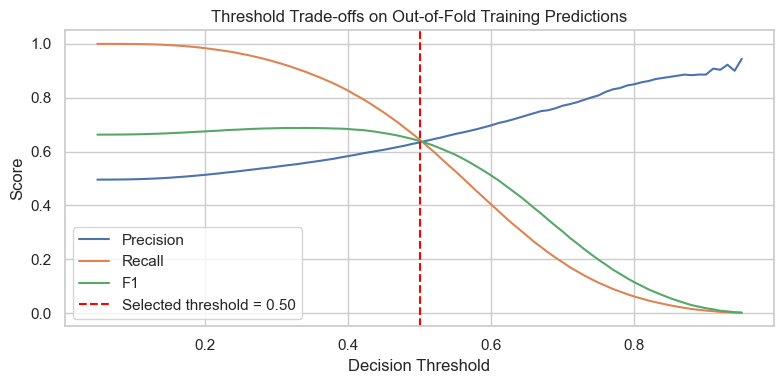

Selected threshold (default): 0.5
Business note: the firm can choose a different operating threshold based on its intervention objective.
Saved: artifacts/threshold.json
Saved: artifacts/figures/threshold_f1.png


In [19]:
# Threshold tuning using TRAIN-only out-of-fold scores
# Part 2 of 3: keep a default threshold of 0.50 for this coursework run.
# The operating threshold should ultimately be chosen by the firm based on business goals
# (for example, maximizing recall, precision, profit, or minimizing intervention cost).

# Confirm the tuned pipeline and artifact paths are already available from Part 1.
required_objects = ['final_pipeline', 'X_train', 'y_train', 'cv', 'artifacts_dir', 'fig_dir']
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(f"Run the first Section 5 cell first. Missing objects: {missing_objects}")

# Generate out-of-fold probabilities for the training set.
# Each row is scored by a model that did not train on that row,
# so this gives a fair train-only view of threshold trade-offs.
oof_proba = cross_val_predict(
    clone(final_pipeline),
    X_train,
    y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=None,
)[:, 1]

# Evaluate a grid of thresholds.
# This does NOT change the selected threshold automatically here;
# it simply shows the precision/recall/F1 trade-off curve.
threshold_rows = []
threshold_grid = np.round(np.arange(0.05, 0.951, 0.01), 2)
for thr in threshold_grid:
    pred_thr = (oof_proba >= thr).astype(int)
    threshold_rows.append(
        {
            'threshold': float(thr),
            'precision': float(precision_score(y_train, pred_thr, zero_division=0)),
            'recall': float(recall_score(y_train, pred_thr, zero_division=0)),
            'f1': float(f1_score(y_train, pred_thr, zero_division=0)),
        }
    )

# Convert the threshold grid results into a DataFrame for inspection and plotting.
threshold_df = pd.DataFrame(threshold_rows)

# Coursework choice: keep the default 0.50 threshold.
# The business should choose the final operating threshold based on intervention costs and goals.
selected_threshold = 0.50
threshold_at_default = threshold_df.loc[np.isclose(threshold_df['threshold'], selected_threshold)].iloc[0]

# Save the chosen threshold and the metric values at that default cut-off.
threshold_path = artifacts_dir / 'threshold.json'
threshold_path.write_text(
    json.dumps(
        {
            'selected_threshold': selected_threshold,
            'selection_rule': 'default_0.50_for_coursework_business_to_choose_operating_threshold',
            'precision_at_threshold': float(threshold_at_default['precision']),
            'recall_at_threshold': float(threshold_at_default['recall']),
            'f1_at_threshold': float(threshold_at_default['f1']),
            'cv_folds_used_for_oof': 3,
        },
        indent=2,
    ),
    encoding='utf-8',
)

# Plot the threshold trade-off curves so the report can show how the operating point changes.
plt.figure(figsize=(8, 4))
plt.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['f1'], label='F1')
plt.axvline(selected_threshold, color='red', linestyle='--', label='Selected threshold = 0.50')
plt.title('Threshold Trade-offs on Out-of-Fold Training Predictions')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
threshold_fig_path = fig_dir / 'threshold_f1.png'
plt.savefig(threshold_fig_path, dpi=150)
plt.show()

print('Selected threshold (default):', selected_threshold)
print('Business note: the firm can choose a different operating threshold based on its intervention objective.')
print('Saved:', threshold_path)
print('Saved:', threshold_fig_path)



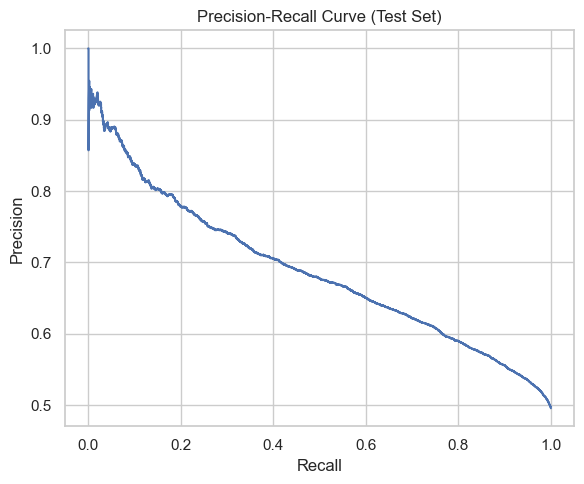

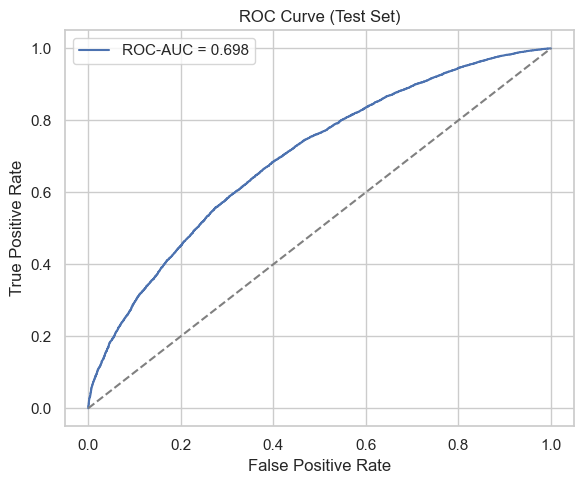

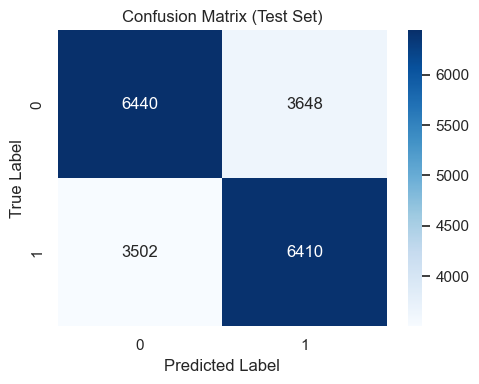

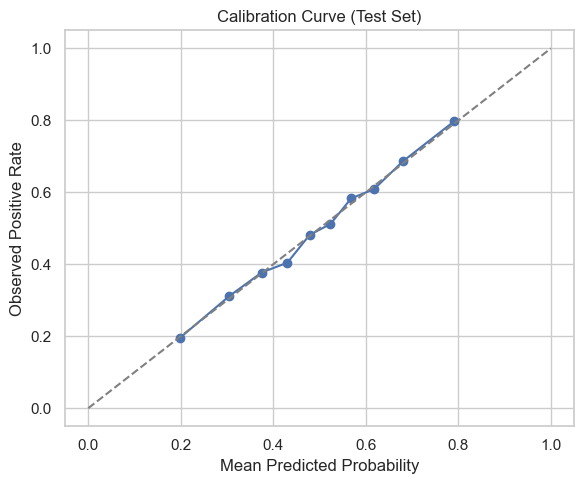

Saved: artifacts/metrics.json
Saved: artifacts/figures/pr_curve.png
Saved: artifacts/figures/roc_curve.png
Saved: artifacts/figures/confusion_matrix.png
Saved: artifacts/figures/calibration_curve.png
Saved: artifacts/error_analysis.csv
Final test metrics:
{
  "selected_model": "XGBoost",
  "selected_threshold": 0.5,
  "test_average_precision": 0.6877399146901937,
  "test_roc_auc": 0.698016254378739,
  "test_precision": 0.6373036388944124,
  "test_recall": 0.6466908797417272,
  "test_f1": 0.6419629444166249
}
Classification report (test):


,precision,recall,f1-score,support
0,0.647757,0.638382,0.643035,10088.0000
1,0.637304,0.646691,0.641963,9912.0000
accuracy,0.642500,0.642500,0.642500,0.6425
macro avg,0.642530,0.642537,0.642499,20000.0000
weighted avg,0.642576,0.642500,0.642504,20000.0000


In [20]:
# Final evaluation on TEST (first time only)
# Part 3 of 3: use the held-out test set once, after model and threshold are fixed.

# Confirm the saved fitted model and threshold metadata exist before scoring the test set.
required_objects = ['best_model_path', 'threshold_path', 'X_test', 'y_test', 'artifacts_dir', 'fig_dir', 'final_model_name']
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(f"Run the first two Section 5 cells first. Missing objects: {missing_objects}")

# Load the persisted final model and the chosen threshold.
# This mirrors a reproducible deployment-style workflow rather than relying only on in-memory state.
final_model = joblib.load(best_model_path)
threshold_meta = json.loads(threshold_path.read_text(encoding='utf-8'))
selected_threshold = float(threshold_meta['selected_threshold'])

# Generate test-set probabilities first, then convert them to class labels using the chosen threshold.
y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= selected_threshold).astype(int)

# Collect the main performance outputs in one metrics dictionary.
# This includes ranking metrics, threshold-dependent metrics, and classification summaries.
# Use the centralized sklearn confusion-matrix function if available; otherwise fall back
# to the original imported name, as long as it is still callable in the current kernel.
confusion_fn = globals().get('sk_confusion_matrix')
if confusion_fn is None:
    fallback_confusion = globals().get('confusion_matrix')
    if callable(fallback_confusion):
        confusion_fn = fallback_confusion
    else:
        raise RuntimeError('Rerun the Library cell so the confusion-matrix metric is available before running this cell.')
metrics = {
    'selected_model': final_model_name,
    'selected_threshold': selected_threshold,
    'test_average_precision': float(average_precision_score(y_test, y_test_proba)),
    'test_roc_auc': float(roc_auc_score(y_test, y_test_proba)),
    'test_precision': float(precision_score(y_test, y_test_pred, zero_division=0)),
    'test_recall': float(recall_score(y_test, y_test_pred, zero_division=0)),
    'test_f1': float(f1_score(y_test, y_test_pred, zero_division=0)),
    'confusion_matrix': confusion_fn(y_test, y_test_pred).tolist(),
    'classification_report': classification_report(y_test, y_test_pred, output_dict=True, zero_division=0),
}

# Save machine-readable metrics for the appendix and reproducibility.
metrics_path = artifacts_dir / 'metrics.json'
metrics_path.write_text(json.dumps(metrics, indent=2), encoding='utf-8')

# Plot 1: precision-recall curve.
# This visualizes how precision changes as recall increases on the held-out test set.
pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_test_proba)
plt.figure(figsize=(6, 5))
plt.plot(pr_recall, pr_precision)
plt.title('Precision-Recall Curve (Test Set)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.tight_layout()
pr_curve_path = fig_dir / 'pr_curve.png'
plt.savefig(pr_curve_path, dpi=150)
plt.show()

# Plot 2: ROC curve.
# This is included as a complementary discrimination view alongside PR-AUC.
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {metrics["test_roc_auc"]:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve (Test Set)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
roc_curve_path = fig_dir / 'roc_curve.png'
plt.savefig(roc_curve_path, dpi=150)
plt.show()

# Plot 3: confusion matrix.
# This makes the false-positive / false-negative trade-off easy to interpret.
cm = np.asarray(metrics['confusion_matrix'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
cm_path = fig_dir / 'confusion_matrix.png'
plt.savefig(cm_path, dpi=150)
plt.show()

# Plot 4: calibration curve.
# This checks whether predicted probabilities are well aligned with observed event rates.
prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=10, strategy='quantile')
plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Calibration Curve (Test Set)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Positive Rate')
plt.tight_layout()
calibration_path = fig_dir / 'calibration_curve.png'
plt.savefig(calibration_path, dpi=150)
plt.show()

# Short error analysis.
# Compare false negatives and true positives across a few important numeric feature splits
# to identify where the model under-detects churn.
error_df = X_test.copy()
error_df['y_true'] = y_test.values
error_df['y_pred'] = y_test_pred
error_df['y_proba'] = y_test_proba
error_df['error_type'] = np.where(
    (error_df['y_true'] == 1) & (error_df['y_pred'] == 0),
    'false_negative',
    np.where((error_df['y_true'] == 1) & (error_df['y_pred'] == 1), 'true_positive', 'other'),
)

# Candidate features are limited to a short list so the output stays readable.
candidate_error_features = [c for c in ['rev_mean', 'mou_mean', 'months', 'totmrc_mean', 'eqpdays'] if c in error_df.columns][:3]
error_rows = []
for feat in candidate_error_features:
    if pd.api.types.is_numeric_dtype(error_df[feat]):
        # Split each feature at the test-set median to create a simple low/high segment.
        median_val = error_df[feat].median(skipna=True)
        for label, mask in {
            f'{feat}_low_or_equal_median': error_df[feat] <= median_val,
            f'{feat}_high': error_df[feat] > median_val,
        }.items():
            subset = error_df[mask & (error_df['error_type'].isin(['false_negative', 'true_positive']))]
            error_rows.append(
                {
                    'feature_segment': label,
                    'median_split_value': float(median_val) if pd.notna(median_val) else None,
                    'false_negatives': int((subset['error_type'] == 'false_negative').sum()),
                    'true_positives': int((subset['error_type'] == 'true_positive').sum()),
                }
            )

# Save the compact error-analysis table for report use.
error_analysis_df = pd.DataFrame(error_rows)
error_analysis_path = artifacts_dir / 'error_analysis.csv'
error_analysis_df.to_csv(error_analysis_path, index=False)

print('Saved:', metrics_path)
print('Saved:', pr_curve_path)
print('Saved:', roc_curve_path)
print('Saved:', cm_path)
print('Saved:', calibration_path)
print('Saved:', error_analysis_path)

# Print a concise summary in the notebook and show the full classification report table.
print('Final test metrics:')
print(json.dumps({k: v for k, v in metrics.items() if k not in {'classification_report', 'confusion_matrix'}}, indent=2))
print('Classification report (test):')
display(pd.DataFrame(metrics['classification_report']).T)



### Section 5 Narrative Notes
- **Why XGBoost and HistGradientBoosting are tuned here**: they were the top 2 models in Section 4, so Section 5 now fine-tunes both and compares their tuned cross-validated PR-AUC before selecting the final model.
- **Why this avoids leakage**: preprocessing, hyperparameter search, and threshold selection are all based on training data only; the test set is untouched until the final evaluation step.
- **Why PR-AUC is primary**: it emphasizes positive-class retrieval quality, which matters for churn intervention targeting.
- **Why 3-fold CV and moderate randomized searches are used**: this is a deliberate runtime-conscious compromise that still allows both top models to be tuned without returning to the original full expensive search.
- **Why early stopping is not used**: it could reduce XGBoost runtime further, but it was not added because it would complicate the cross-validated tuning workflow and reduce methodological transparency for this coursework.
- **Why a default 0.50 threshold is used here**: this keeps the evaluation simple and neutral for coursework; in practice, the firm should set the operating threshold based on its objective (for example, maximizing recall, precision, or business value).
- **Why out-of-fold training probabilities are still plotted**: they show how precision/recall/F1 change across thresholds without using the test set.
- **Test-set policy**: the held-out test set is used once, only after model and threshold decisions are completed.



## 6) Present the final solution
Summarize the final selected model, business interpretation, deployment plan, risks, and next-step improvements using the artifacts already saved in Section 5. This section does **not** rerun modelling and does **not** touch the test set again.


In [21]:
# Section 6: Final solution and deployment considerations
# This section is a reporting layer only.
# It reads the saved artifacts from Section 5 and converts them into a concise,
# evidence-based final summary without rerunning any modelling.



# Show full text in narrative tables instead of truncating long cell content.
pd.set_option('display.max_colwidth', None)

artifacts_dir = Path('artifacts')
metrics_path = artifacts_dir / 'metrics.json'
threshold_path = artifacts_dir / 'threshold.json'
summary_path = artifacts_dir / 'tuning_summary.json'
tuning_results_path = artifacts_dir / 'tuning_results.csv'
split_config_path = artifacts_dir / 'split_config.json'

required_files = [metrics_path, threshold_path, summary_path, tuning_results_path, split_config_path]
missing_files = [str(p) for p in required_files if not p.exists()]
if missing_files:
    raise FileNotFoundError(
        'Run Section 5 first so the required artifacts exist. Missing: ' + ', '.join(missing_files)
    )

# Load the saved machine-readable outputs from earlier sections.
# These are the authoritative sources for the final narrative, so no numbers are fabricated.
metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
threshold_meta = json.loads(threshold_path.read_text(encoding='utf-8'))
tuning_summary = json.loads(summary_path.read_text(encoding='utf-8'))
tuning_results = pd.read_csv(tuning_results_path)
split_config = json.loads(split_config_path.read_text(encoding='utf-8'))

selected_model = metrics['selected_model']
selected_threshold = float(metrics['selected_threshold'])
model_summary = tuning_summary.get(selected_model, {})
best_params = model_summary.get('best_params', {})
cv_best_pr_auc = model_summary.get('best_score_cv_average_precision', np.nan)
cv_folds = model_summary.get('cv_folds', None)

# Pull the best row from tuning results so we can comment on CV variability and train-vs-validation gap.
best_tuning_row = tuning_results.sort_values('rank_test_score').iloc[0]
cv_pr_auc_std = float(best_tuning_row['std_test_score'])
cv_pr_auc_train = float(best_tuning_row['mean_train_score'])
cv_pr_auc_gap = float(best_tuning_row['mean_train_score'] - best_tuning_row['mean_test_score'])

# Core final metrics from the held-out test set.
# These are the final externally reported numbers because the test set was used only once.
test_pr_auc = float(metrics['test_average_precision'])
test_roc_auc = float(metrics['test_roc_auc'])
test_precision = float(metrics['test_precision'])
test_recall = float(metrics['test_recall'])
test_f1 = float(metrics['test_f1'])
cm_array = np.asarray(metrics['confusion_matrix'])

tn, fp, fn, tp = cm_array.ravel()

# Business translation example for 10,000 scored customers.
# Use the observed held-out test prevalence as a simple proxy for the expected churn rate.
# This is only an illustrative scaling exercise, not a deployment forecast.
example_n = 10_000
estimated_prevalence = float(split_config['target_positive_rate_test'])
estimated_actual_churners = int(round(example_n * estimated_prevalence))
estimated_true_positives = int(round(estimated_actual_churners * test_recall))
estimated_predicted_positives = int(round(estimated_true_positives / test_precision)) if test_precision > 0 else 0
estimated_false_positives = max(estimated_predicted_positives - estimated_true_positives, 0)

# 1) Final model summary table.
# This gives a compact, report-ready view of the final selected configuration and outcomes.
final_model_summary = pd.DataFrame([
    {
        'Selected model': selected_model,
        'CV PR-AUC (best mean)': round(float(cv_best_pr_auc), 4) if pd.notna(cv_best_pr_auc) else np.nan,
        'CV PR-AUC std': round(cv_pr_auc_std, 4),
        'Selected threshold': round(selected_threshold, 2),
        'Test PR-AUC': round(test_pr_auc, 4),
        'Test ROC-AUC': round(test_roc_auc, 4),
        'Test Precision': round(test_precision, 4),
        'Test Recall': round(test_recall, 4),
        'Test F1': round(test_f1, 4),
    }
])
print('Final model summary:')
display(final_model_summary.style.hide(axis='index'))

print('Best hyperparameters (from saved tuning artifact):')
print(json.dumps(best_params, indent=2))

# 2) Business interpretation.
# Translate the classification metrics into retention-campaign implications.
print('Business interpretation:')
print(
    f'- Recall of {test_recall:.2%} means the model identifies roughly {test_recall:.0%} of actual churners, '
    'which is useful when missing a likely churner is costly.'
)
print(
    f'- Precision of {test_precision:.2%} means only about {test_precision:.0%} of customers flagged as churn risk '
    'are true churners, so retention campaigns will still contact a meaningful number of customers who would not churn.'
)
print(
    f'- Example for {example_n:,} scored customers (using the observed test prevalence as a rough proxy): '
    f'about {estimated_predicted_positives:,} would be flagged as likely churners, '
    f'around {estimated_true_positives:,} of those would be true churners captured, '
    f'and roughly {estimated_false_positives:,} would be false positives.'
)

# 3) Operational deployment plan.
# Describe how the saved pipeline would be used in practice.
deployment_points = pd.DataFrame({
    'Deployment component': [
        'Scoring workflow',
        'Decision rule',
        'Retraining cadence',
        'Production monitoring',
    ],
    'Recommended approach': [
        'Use the saved pipeline to run `predict_proba` on new customer records after the same input schema checks.',
        f'Apply the current threshold of {selected_threshold:.2f}; in production, this threshold should be set by the firm based on campaign cost and capacity.',
        'Retrain on a regular cadence (for example monthly or quarterly) or sooner if customer behavior changes materially.',
        'Monitor PR-AUC, precision/recall at the operating threshold, calibration, input drift, and churn prevalence drift over time.',
    ],
})
print('Operational deployment plan:')
display(deployment_points.style.hide(axis='index').set_properties(**{'white-space': 'normal', 'text-align': 'left'}))

# 4) Model risk and limitations.
# These notes explain where the reported test performance may not fully generalize.
risk_points = pd.DataFrame({
    'Risk area': [
        'Balanced sample vs real deployment base rate',
        'Sampling bias',
        'Probability calibration',
        'Concept drift',
        'Overfitting / stability',
    ],
    'Implication': [
        'The working dataset is more balanced than many real-world churn populations, so absolute precision / PR-AUC may look more favorable than in production.',
        "The Kaggle sample may not perfectly reflect the firm's current customer base, product mix, or channel mix.",
        'Predicted probabilities may not be perfectly calibrated, so threshold choices based on raw scores should be reviewed carefully.',
        'Telecom churn behavior changes over time with pricing, competitors, and campaigns, so model performance can decay after deployment.',
        f'The best tuning result has CV PR-AUC std of about {cv_pr_auc_std:.4f}; this suggests some fold-to-fold variability and should be monitored rather than assuming fully stable performance.',
    ],
})
print('Model risks and limitations:')
display(risk_points.style.hide(axis='index').set_properties(**{'white-space': 'normal', 'text-align': 'left'}))
print(f'Observed train-vs-validation PR-AUC gap at the best tuning row: {cv_pr_auc_gap:.4f}')

# 5) Ethical and fairness considerations.
# Keep this brief but explicit, because some features have demographic content.
fairness_points = pd.DataFrame({
    'Fairness consideration': [
        'Demographic-feature use',
        'Biased targeting risk',
        'Pre-deployment review',
    ],
    'Why it matters': [
        'Features such as income or household proxies can encode socioeconomic differences, so their use should be justified and monitored carefully.',
        'A churn model can unintentionally direct incentives or retention offers unevenly across customer groups.',
        'Before deployment, the firm should run fairness checks across relevant segments and confirm the intervention policy is consistent with internal governance.',
    ],
})
print('Ethical and fairness considerations:')
display(fairness_points.style.hide(axis='index').set_properties(**{'white-space': 'normal', 'text-align': 'left'}))

# 6) Improvement roadmap.
# These are concrete next steps grounded in the current modelling results.
improvement_roadmap = pd.DataFrame({
    'Priority improvement': [
        'Cost-sensitive threshold tuning',
        'Probability calibration',
        'Additional feature engineering',
        'External data enrichment',
        'Business cost-based optimization',
    ],
    'Why it helps': [
        'The current 0.50 threshold is neutral; a business-calibrated threshold can better balance false positives and false negatives.',
        'Calibration methods such as Platt scaling or isotonic regression can make predicted probabilities more decision-useful.',
        'Additional behavior-change, overage-stress, and service-friction features may improve discrimination.',
        'Adding campaign history, complaints, plan changes, or network quality data could capture churn drivers not visible in the current dataset.',
        'Optimizing directly for expected retention value would align the model with campaign ROI rather than generic classification metrics.',
    ],
})
print('Improvement roadmap:')
display(improvement_roadmap.style.hide(axis='index').set_properties(**{'white-space': 'normal', 'text-align': 'left'}))

# 7) Concluding paragraph.
# This is a concise final narrative that can be adapted into the written report.
conclusion_lines = [
    f'The final selected model is {selected_model}, tuned on the training set using cross-validation and evaluated once on the held-out test set.',
    f'Its test performance is moderate rather than exceptional, with PR-AUC {test_pr_auc:.3f}, ROC-AUC {test_roc_auc:.3f}, precision {test_precision:.3f}, recall {test_recall:.3f}, and F1 {test_f1:.3f} at the selected threshold of {selected_threshold:.2f}.',
    'Operationally, the model is most useful as a prioritization tool for retention outreach rather than as a highly precise classifier.',
    'The current results should be interpreted cautiously because the sample may be more balanced than a real deployment population, probabilities may require calibration, and telecom churn behavior can drift over time.',
    f'CV variability is present (best-row PR-AUC std {cv_pr_auc_std:.3f}), so performance should be monitored after deployment rather than assumed stable.',
    'The most practical next steps are to choose a cost-sensitive threshold, improve probability calibration, and enrich the feature set with additional business context.',
]
print('Conclusion:')
for line in conclusion_lines:
    print(line)



Final model summary:


Selected model,CV PR-AUC (best mean),CV PR-AUC std,Selected threshold,Test PR-AUC,Test ROC-AUC,Test Precision,Test Recall,Test F1
XGBoost,0.680000,0.003700,0.500000,0.687700,0.698000,0.637300,0.646700,0.642000


Best hyperparameters (from saved tuning artifact):
{
  "model__subsample": 0.6,
  "model__reg_lambda": 1.0,
  "model__reg_alpha": 0.5,
  "model__n_estimators": 600,
  "model__min_child_weight": 8,
  "model__max_depth": 5,
  "model__learning_rate": 0.05,
  "model__gamma": 0.5,
  "model__colsample_bytree": 0.8
}
Business interpretation:
- Recall of 64.67% means the model identifies roughly 65% of actual churners, which is useful when missing a likely churner is costly.
- Precision of 63.73% means only about 64% of customers flagged as churn risk are true churners, so retention campaigns will still contact a meaningful number of customers who would not churn.
- Example for 10,000 scored customers (using the observed test prevalence as a rough proxy): about 5,029 would be flagged as likely churners, around 3,205 of those would be true churners captured, and roughly 1,824 would be false positives.
Operational deployment plan:


Deployment component,Recommended approach
Scoring workflow,Use the saved pipeline to run `predict_proba` on new customer records after the same input schema checks.
Decision rule,"Apply the current threshold of 0.50; in production, this threshold should be set by the firm based on campaign cost and capacity."
Retraining cadence,Retrain on a regular cadence (for example monthly or quarterly) or sooner if customer behavior changes materially.
Production monitoring,"Monitor PR-AUC, precision/recall at the operating threshold, calibration, input drift, and churn prevalence drift over time."


Model risks and limitations:


...

Observed train-vs-validation PR-AUC gap at the best tuning row: 0.1276
Ethical and fairness considerations:


Fairness consideration,Why it matters
Demographic-feature use,"Features such as income or household proxies can encode socioeconomic differences, so their use should be justified and monitored carefully."
Biased targeting risk,A churn model can unintentionally direct incentives or retention offers unevenly across customer groups.
Pre-deployment review,"Before deployment, the firm should run fairness checks across relevant segments and confirm the intervention policy is consistent with internal governance."


Improvement roadmap:


Priority improvement,Why it helps
Cost-sensitive threshold tuning,The current 0.50 threshold is neutral; a business-calibrated threshold can better balance false positives and false negatives.
Probability calibration,Calibration methods such as Platt scaling or isotonic regression can make predicted probabilities more decision-useful.
Additional feature engineering,"Additional behavior-change, overage-stress, and service-friction features may improve discrimination."
External data enrichment,"Adding campaign history, complaints, plan changes, or network quality data could capture churn drivers not visible in the current dataset."
Business cost-based optimization,Optimizing directly for expected retention value would align the model with campaign ROI rather than generic classification metrics.


Conclusion:
The final selected model is XGBoost, tuned on the training set using cross-validation and evaluated once on the held-out test set.
Its test performance is moderate rather than exceptional, with PR-AUC 0.688, ROC-AUC 0.698, precision 0.637, recall 0.647, and F1 0.642 at the selected threshold of 0.50.
Operationally, the model is most useful as a prioritization tool for retention outreach rather than as a highly precise classifier.
The current results should be interpreted cautiously because the sample may be more balanced than a real deployment population, probabilities may require calibration, and telecom churn behavior can drift over time.
CV variability is present (best-row PR-AUC std 0.004), so performance should be monitored after deployment rather than assumed stable.
The most practical next steps are to choose a cost-sensitive threshold, improve probability calibration, and enrich the feature set with additional business context.
